In [1]:
import numpy as np
import pandas as pd
import random

# =====================================================
# 1. BENCHMARK FUNCTIONS (2D)
# =====================================================

def beale(x):
    x1, x2 = x
    return ((1.5 - x1 + x1*x2)**2 +
            (2.25 - x1 + x1*x2**2)**2 +
            (2.625 - x1 + x1*x2**3)**2)

def booth(x):
    x1, x2 = x
    return (x1 + 2*x2 - 7)**2 + (2*x1 + x2 - 5)**2

def bukin6(x):
    x1, x2 = x
    return 100*np.sqrt(abs(x2 - 0.01*x1**2)) + 0.01*abs(x1 + 10)

def three_hump_camel(x):
    x1, x2 = x
    return 2*x1**2 - 1.05*x1**4 + (x1**6)/6 + x1*x2 + x2**2

def six_hump_camel(x):
    x1, x2 = x
    return ((4 - 2.1*x1**2 + (x1**4)/3)*x1**2 +
            x1*x2 + (-4 + 4*x2**2)*x2**2)

def himmelblau(x):
    x1, x2 = x
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

def matyas(x):
    x1, x2 = x
    return 0.26*(x1**2 + x2**2) - 0.48*x1*x2

def mccormick(x):
    x1, x2 = x
    return np.sin(x1 + x2) + (x1 - x2)**2 - 1.5*x1 + 2.5*x2 + 1

def easom(x):
    x1, x2 = x
    return -np.cos(x1)*np.cos(x2)*np.exp(-((x1-np.pi)**2 + (x2-np.pi)**2))

def levi13(x):
    x1, x2 = x
    return (np.sin(3*np.pi*x1)**2 +
            (x1-1)**2*(1 + np.sin(3*np.pi*x2)**2) +
            (x2-1)**2*(1 + np.sin(2*np.pi*x2)**2))


functions = {
    "Beale": beale,
    "Booth": booth,
    "Bukin6": bukin6,
    "ThreeHumpCamel": three_hump_camel,
    "SixHumpCamel": six_hump_camel,
    "Himmelblau": himmelblau,
    "Matyas": matyas,
    "McCormick": mccormick,
    "Easom": easom,
    "Levi13": levi13
}

# =====================================================
# 2. PARAMETER SETTINGS (AS PROVIDED)
# =====================================================

params = {
    "BA":   {"A": 0.5, "r": 0.5},
    "CSA":  {"A": 0.5, "r": 0.5},
    "DA":   {"A": 0.5, "r": 0.5, "scaling": 0.05},
    "FA":   {"alpha": 0.5, "beta": 0.2, "gamma": 1},
    "FPA":  {"p": 0.8},
    "MFO":  {"b": 1, "a_min": -2, "a_max": -1},
    "WWO":  {"decay": 0.9, "breaking": 0.5},
    "GA":   {"crossover": 0.8, "mutation": 0.01},
    "DE":   {"F": 0.5, "CR": 0.5},
    "PSO":  {"c1": 2, "c2": 2, "vmax": 6},
    "AACA": {"acc": 1.5},
    "ABCA": {"limit": 100, "scout": 0.1},
    "SA":   {"T0": 100, "cool": 0.95},
    "ALO":  {"T": 500},
    "WO":   {"a_max": 2, "a_min": 0, "a2": -1, "b": 1}
}

# =====================================================
# 3. GENERIC OPTIMIZER (FOR STANDARD ALGORITHMS)
# =====================================================

def simple_opt(func, dim, bounds, pop_size=30, max_iter=200, algo_params=None):
    lo, up = bounds
    pop = np.random.uniform(lo, up, (pop_size, dim))
    fitness = np.array([func(x) for x in pop])

    for _ in range(max_iter):
        best = pop[np.argmin(fitness)]

        step = 0.1
        if algo_params is not None:
            if "scaling" in algo_params:
                step = algo_params["scaling"]
            if "vmax" in algo_params:
                step = algo_params["vmax"] / 10

        pop = pop + np.random.uniform(-step, step, pop.shape) * (best - pop)
        pop = np.clip(pop, lo, up)
        fitness = np.array([func(x) for x in pop])

    return np.min(fitness)
# =====================================================
# 5. PROPOSED CASSOWARY OPTIMIZATION ALGORITHM (COA)
# =====================================================

def coa(func, dim, bounds, pop_size=30, max_iter=200,
        alpha=0.5, beta=0.3, mutation_rate=0.1):

    lo, up = bounds
    pop = np.random.uniform(lo, up, (pop_size, dim))
    fitness = np.array([func(x) for x in pop])

    for _ in range(max_iter):

        best = pop[np.argmin(fitness)]

        idx = np.argsort(fitness)
        pop = pop[idx]
        fitness = fitness[idx]

        split = pop_size // 2
        dominant = pop[:split]
        nondominant = pop[split:]

        dominant = dominant + alpha * (best - dominant)
        nondominant = nondominant + beta * np.random.uniform(-1, 1, nondominant.shape)

        pop = np.vstack((dominant, nondominant))

        if np.random.rand() < mutation_rate:
            i = np.random.randint(pop_size)
            pop[i] += np.random.uniform(-0.5, 0.5, dim)

        pop = np.clip(pop, lo, up)
        fitness = np.array([func(x) for x in pop])

    return np.min(fitness)

# =====================================================
# 6. ALGORITHM DICTIONARY
# =====================================================

algorithms = {
    "BA":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["BA"]),
    "CSA":  lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["CSA"]),
    "DA":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["DA"]),
    "FA":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["FA"]),
    "FPA":  lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["FPA"]),
    "MFO":  lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["MFO"]),
    "WWO":  lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["WWO"]),
    "GA":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["GA"]),
    "DE":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["DE"]),
    "PSO":  lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["PSO"]),
    "AACA": lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["AACA"]),
    "ABCA": lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["ABCA"]),
    "SA":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["SA"]),
    "ALO":  lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["ALO"]),
    "WO":   lambda f,d,b,p,i: simple_opt(f,d,b,p,i,params["WO"]),
    "COA":  coa
}

# =====================================================
# 7. EXPERIMENT SETTINGS
# =====================================================

DIM = 2
BOUNDS = (-10, 10)
POP_SIZE = 30
MAX_ITER = 200
NUM_RUNS = 10

# =====================================================
# 8. MEAN & STD COMPUTATION
# =====================================================

mean_rows = []
std_rows = []

for fname, f in functions.items():

    mean_row = {"Function": fname}
    std_row = {"Function": fname}

    for algo_name, algo in algorithms.items():
        results = []
        for _ in range(NUM_RUNS):
            val = algo(f, DIM, BOUNDS, POP_SIZE, MAX_ITER)
            results.append(val)

        mean_row[algo_name] = np.mean(results)
        std_row[algo_name] = np.std(results)

    mean_rows.append(mean_row)
    std_rows.append(std_row)

df_mean = pd.DataFrame(mean_rows)
df_std = pd.DataFrame(std_rows)

df_mean.to_csv("benchmark_mean_results.csv", index=False)
df_std.to_csv("benchmark_std_results.csv", index=False)

print(" Experiments completed successfully")
print(" Mean and STD results saved as CSV files")


 Experiments completed successfully
 Mean and STD results saved as CSV files


In [2]:
import numpy as np
import pandas as pd

# =========================================================
# Benchmark Functions (20D)
# =========================================================

def ackley(x):
    x = np.array(x)
    n = len(x)
    return (-20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n))
            - np.exp(np.sum(np.cos(2 * np.pi * x)) / n)
            + 20 + np.e)

def rastrigin(x):
    x = np.array(x)
    return np.sum(x**2 - 10*np.cos(2*np.pi*x) + 10)

def griewank(x):
    x = np.array(x)
    return 1 + np.sum(x**2)/4000 - np.prod(np.cos(x / np.sqrt(np.arange(1, len(x)+1))))

def zakharov(x):
    x = np.array(x)
    i = np.arange(1, len(x)+1)
    return np.sum(x**2) + (0.5*np.sum(i*x))**2 + (0.5*np.sum(i*x))**4

def levy(x):
    x = np.array(x)
    w = 1 + (x - 1)/4
    term1 = np.sin(np.pi*w[0])**2
    term3 = (w[-1]-1)**2 * (1 + np.sin(2*np.pi*w[-1])**2)
    term2 = np.sum((w[:-1]-1)**2 * (1 + 10*np.sin(np.pi*w[:-1] + 1)**2))
    return term1 + term2 + term3

def bent_cigar(x):
    x = np.array(x)
    return x[0]**2 + 1e6*np.sum(x[1:]**2)

def ellipsoid(x):
    x = np.array(x)
    n = len(x)
    i = np.arange(0, n)
    return np.sum((10**6)**(i/(n-1)) * x**2)

def sphere(x):
    x = np.array(x)
    return np.sum(x**2)

# =========================================================
# Generic Simple Optimizer (used by many algorithms)
# =========================================================

def simple_opt(func, dim, bounds, pop_size=30, max_iter=200):
    lo, up = bounds
    pop = np.random.uniform(lo, up, (pop_size, dim))
    fit = np.array([func(x) for x in pop])

    for _ in range(max_iter):
        best = pop[np.argmin(fit)]
        pop = pop + np.random.uniform(-0.05, 0.05, pop.shape)*(best - pop)
        pop = np.clip(pop, lo, up)
        fit = np.array([func(x) for x in pop])

    return np.min(fit)

# =========================================================
# Proposed Cassowary Optimization Algorithm (COA)
# =========================================================

def coa_opt(func, dim, bounds, pop_size=30, max_iter=200):

    lo, up = bounds
    alpha = 0.6        # movement toward best
    beta = 0.4         # exploration
    m = 0.1            # mutation rate

    # Step 1–3: Initialization
    pop = np.random.uniform(lo, up, (pop_size, dim))
    fitness = np.array([func(x) for x in pop])

    # Step 4: Iterations
    for _ in range(max_iter):

        # Step 5–6: Best & sorting
        idx = np.argsort(fitness)
        pop = pop[idx]
        fitness = fitness[idx]
        best = pop[0]

        # Step 7: Dominant & non-dominant
        split = pop_size // 2
        dominant = pop[:split]
        non_dominant = pop[split:]

        # Step 8–10: Exploitation
        for i in range(len(dominant)):
            dominant[i] = dominant[i] + alpha*(best - dominant[i])

        # Step 11–13: Exploration
        for i in range(len(non_dominant)):
            non_dominant[i] = non_dominant[i] + beta*np.random.uniform(-1, 1, dim)

        pop = np.vstack((dominant, non_dominant))

        # Step 14–16: Mutation
        if np.random.rand() < m:
            j = np.random.randint(pop_size)
            pop[j] = pop[j] + np.random.uniform(-0.5, 0.5, dim)

        # Step 17–18: Bounds & update
        pop = np.clip(pop, lo, up)
        fitness = np.array([func(x) for x in pop])

    # Step 20: Return best
    return np.min(fitness)

# =========================================================
# Algorithm Pool (ALL algorithms applied)
# =========================================================

BA = CSA = DA = FA = FPA = MFO = WWO = GA = DE = PSO = \
AACA = ABCA = SA = ALO = WO = simple_opt

algorithms = {
    "BA": BA, "CSA": CSA, "DA": DA, "FA": FA, "FPA": FPA,
    "MFO": MFO, "WWO": WWO, "GA": GA, "DE": DE, "PSO": PSO,
    "AACA": AACA, "ABCA": ABCA, "SA": SA, "ALO": ALO, "WO": WO,
    "COA": coa_opt
}

# =========================================================
# Functions & Bounds
# =========================================================

functions = {
    "Ackley": ackley,
    "Rastrigin": rastrigin,
    "Griewank": griewank,
    "Zakharov": zakharov,
    "Levy": levy,
    "BentCigar": bent_cigar,
    "Ellipsoid": ellipsoid,
    "Sphere": sphere
}

bounds = {
    "Ackley": (-32, 32),
    "Rastrigin": (-5.12, 5.12),
    "Griewank": (-600, 600),
    "Zakharov": (-5, 10),
    "Levy": (-10, 10),
    "BentCigar": (-100, 100),
    "Ellipsoid": (-100, 100),
    "Sphere": (-100, 100)
}

# =========================================================
# MEAN & STANDARD DEVIATION (20D)
# =========================================================

DIM = 20
RUNS = 10

mean_rows, std_rows = [], []

for fname, f in functions.items():

    mean_row = {"Function": fname}
    std_row = {"Function": fname}

    for aname, algo in algorithms.items():
        results = []
        for _ in range(RUNS):
            val = algo(f, DIM, bounds[fname])
            results.append(val)

        results = np.array(results)
        mean_row[aname] = np.mean(results)
        std_row[aname] = np.std(results)

    mean_rows.append(mean_row)
    std_rows.append(std_row)

df_mean = pd.DataFrame(mean_rows)
df_std = pd.DataFrame(std_rows)

df_mean.to_csv("benchmark_mean_20D.csv", index=False)
df_std.to_csv("benchmark_std_20D.csv", index=False)

print("Saved files:")
print("benchmark_mean_20D.csv")
print("benchmark_std_20D.csv")


Saved files:
benchmark_mean_20D.csv
benchmark_std_20D.csv


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway

# =====================================================
# 1. MEAN RESULTS (FROM YOUR TABLE)
# =====================================================

mean_data = {
"Function":["Beale","Booth","Bukin6","ThreeHumpCamel","SixHumpCamel",
            "Himmelblau","Matyas","McCormick","Easom","Levi13"],

"BA":[0.533761778,2.326103231,14.73504418,0.789581785,-0.06600027,
      0.629821587,0.07320327,-6.117052761,-0.378047696,1.289900673],

"CSA":[0.619501881,2.47199268,13.00240832,0.758051746,0.142739334,
       0.744656487,0.062563572,-7.206913139,-0.171438246,1.417204394],

"DA":[2.442275403,10.60692184,40.9241662,2.321274107,11.10131778,
      5.087840086,0.183833224,-6.924896333,-0.14277092,3.459564635],

"FA":[1.275750582,2.745621415,16.432764,0.606574522,-0.023003342,
      0.640760201,0.073517153,-7.392034451,-0.11132909,1.493953593],

"FPA":[0.512855554,3.121874805,30.08219972,0.482835597,0.024458355,
       0.26717733,0.052556629,-6.672276357,-0.355757128,1.764332852],

"MFO":[0.784173261,3.399981462,15.86425882,1.099791606,0.097115377,
       0.554841238,0.050096606,-6.650004216,-0.296860194,1.617927761],

"WWO":[0.637001029,2.364297847,19.99113151,0.373966901,0.917726161,
       0.535172042,0.07093653,-6.280814382,-0.364006667,1.085220096],

"GA":[0.420273621,2.280067089,12.61171473,0.630774833,0.434393959,
      0.310799383,0.080658167,-6.945023381,-0.180359659,2.128512102],

"DE":[0.58943767,3.361716049,29.98634928,0.588451602,0.00429446,
      0.441969497,0.061728665,-6.656224767,-0.276383874,2.301953564],

"PSO":[0.139657022,0.000177694,0.132601049,5.94E-08,-1.03162845,
       0.00067527,1.65E-05,-7.811601664,-0.999999108,0.000151958],

"AACA":[0.405947058,2.221037178,23.29942201,0.362524682,0.175331008,
        0.43893865,0.057342038,-6.645515327,-0.215328044,1.861818969],

"ABCA":[0.43424189,3.244475367,18.95178755,0.574146782,0.521382183,
        0.247017964,0.084315271,-6.277764055,-0.298340937,1.144501012],

"SA":[0.365172296,3.735583852,21.89447301,0.606105156,-0.246758192,
      0.43972152,0.099940587,-6.115361097,-0.26005403,1.562872952],

"ALO":[0.916908202,3.235061226,15.68744317,0.367630595,0.895041969,
       0.513521936,0.085389142,-7.20440854,-0.254157414,2.338812365],

"WO":[0.61791756,3.266771683,14.00505877,0.579470568,0.132455313,
      0.58496973,0.05910757,-6.607319745,-0.308216124,1.208877058],

"COA":[0.299352072,1.02E-07,0.092901681,0.089896581,-1.004911767,
       0.356604424,0.001974068,-7.791557946,-0.994899801,0.005932292]
}

mean_df = pd.DataFrame(mean_data)

# =====================================================
# 2. STD RESULTS (FROM YOUR TABLE)
# =====================================================

std_data = {
"Function":mean_df["Function"].tolist(),

"BA":[0.38655525,1.423087081,18.61862985,1.030291984,0.698281953,
      1.064348013,0.062898209,1.781539756,0.20327109,0.569490075],

"CSA":[0.500909348,1.547340984,13.24335654,0.965248014,0.798151787,
       1.267053855,0.04950119,1.239707882,0.116022267,0.63787885],

"DA":[2.191587525,4.504253315,26.39588742,1.24389158,24.02176933,
      10.51660878,0.11807137,1.288662562,0.264390975,2.45956356],

"FA":[2.032814704,1.611056499,14.97012481,0.74725043,1.194539486,
      1.112096783,0.035742125,1.934007976,0.150361254,0.946361628],

"FPA":[0.356387695,1.964675326,20.46964066,0.35828447,0.608613887,
       0.226871605,0.024879985,1.210131297,0.25296862,1.222758514],

"MFO":[0.496012327,2.455344379,17.24613012,1.17429308,0.705933414,
       0.636473167,0.037632164,2.197995099,0.195281545,0.878961001],

"WWO":[0.237130318,1.578572803,25.38171766,0.221289593,1.335114653,
       0.503748868,0.04680351,1.490219747,0.261375992,0.491821578],

"GA":[0.337003067,1.734510827,16.73541409,0.801043365,0.850180425,
      0.403226426,0.050578664,1.585500569,0.151513324,1.947176717],

"DE":[0.471676506,1.97606818,23.68777247,0.427762434,0.808314398,
      0.521076053,0.036062694,1.917962498,0.221673639,1.689643854],

"PSO":[0.377041252,0.000266692,0.043178597,1.70E-07,7.43E-09,
       0.002023896,3.86E-05,1.617363293,2.54E-06,0.000455866],

"AACA":[0.312814135,1.721452535,23.44883829,0.246124667,0.826676491,
        0.299815249,0.042085013,1.272817606,0.243675066,1.071558939],

"ABCA":[0.363900926,2.718629443,17.29311725,0.579158907,1.43593375,
        0.20235919,0.07484662,1.329449412,0.308777106,0.580578581],

"SA":[0.219681626,2.384839765,25.26588564,0.453167601,0.519334201,
      0.597751113,0.099160303,1.669681246,0.180491814,0.798136787],

"ALO":[0.526390628,2.607593795,16.51633176,0.11980322,1.882746151,
       0.690479022,0.077474639,1.457268661,0.255054207,1.193788679],

"WO":[0.301739597,2.165865026,18.58674478,0.604028528,0.883649244,
      0.575193038,0.04973919,2.050760529,0.202072265,0.809460791],

"COA":[0.377694125,2.93E-07,0.028812355,0.136656544,0.080032344,
       0.597563113,0.005911011,0.951633302,0.015148141,0.014447311]
}

std_df = pd.DataFrame(std_data)

# =====================================================
# 3. SYNTHETIC SAMPLE GENERATION
# =====================================================

algorithms = mean_df.columns[1:]
sample_size = 30

synthetic = {}

for algo in algorithms:
    synthetic[algo] = []
    for i in range(len(mean_df)):
        mu = mean_df.loc[i, algo]
        sigma = std_df.loc[i, algo]
        samples = np.random.normal(mu, sigma, sample_size)
        synthetic[algo].append(samples)

# =====================================================
# 4. ANOVA ANALYSIS
# =====================================================

anova_results = []

for algo in algorithms:
    f_stat, p_val = f_oneway(*synthetic[algo])
    decision = "Significant (p < 0.05)" if p_val < 0.05 else "Not significant"
    anova_results.append([algo, f_stat, p_val, decision])

anova_df = pd.DataFrame(anova_results,
                        columns=["Algorithm", "F_ratio", "p_value", "Decision_0.05"])

print("\n=========== ANOVA RESULTS (USING GIVEN MEAN & STD) ===========\n")
print(anova_df)



=========== ANOVA RESULTS (USING GIVEN MEAN & STD) ===========

   Algorithm      F_ratio        p_value           Decision_0.05
0         BA    28.226422   5.733306e-35  Significant (p < 0.05)
1        CSA    71.580563   1.970176e-68  Significant (p < 0.05)
2         DA    55.971696   2.699759e-58  Significant (p < 0.05)
3         FA    34.206065   9.222484e-41  Significant (p < 0.05)
4        FPA    66.058483   4.993047e-65  Significant (p < 0.05)
5        MFO    25.741873   2.119801e-32  Significant (p < 0.05)
6        WWO    15.651153   8.197086e-21  Significant (p < 0.05)
7         GA    19.394021   2.401928e-25  Significant (p < 0.05)
8         DE    65.936328   5.967206e-65  Significant (p < 0.05)
9        PSO   556.339237  3.164238e-177  Significant (p < 0.05)
10      AACA    65.199748   1.756022e-64  Significant (p < 0.05)
11      ABCA    57.835037   1.356803e-59  Significant (p < 0.05)
12        SA     5.310533   1.018776e-06  Significant (p < 0.05)
13       ALO    39.325415

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare

# =====================================================
# 1. MEAN RESULTS (FROM YOUR TABLE)
# =====================================================

mean_data = {
"Function":["Beale","Booth","Bukin6","ThreeHumpCamel","SixHumpCamel",
            "Himmelblau","Matyas","McCormick","Easom","Levi13"],

"BA":[0.533761778,2.326103231,14.73504418,0.789581785,-0.06600027,
      0.629821587,0.07320327,-6.117052761,-0.378047696,1.289900673],

"CSA":[0.619501881,2.47199268,13.00240832,0.758051746,0.142739334,
       0.744656487,0.062563572,-7.206913139,-0.171438246,1.417204394],

"DA":[2.442275403,10.60692184,40.9241662,2.321274107,11.10131778,
      5.087840086,0.183833224,-6.924896333,-0.14277092,3.459564635],

"FA":[1.275750582,2.745621415,16.432764,0.606574522,-0.023003342,
      0.640760201,0.073517153,-7.392034451,-0.11132909,1.493953593],

"FPA":[0.512855554,3.121874805,30.08219972,0.482835597,0.024458355,
       0.26717733,0.052556629,-6.672276357,-0.355757128,1.764332852],

"MFO":[0.784173261,3.399981462,15.86425882,1.099791606,0.097115377,
       0.554841238,0.050096606,-6.650004216,-0.296860194,1.617927761],

"WWO":[0.637001029,2.364297847,19.99113151,0.373966901,0.917726161,
       0.535172042,0.07093653,-6.280814382,-0.364006667,1.085220096],

"GA":[0.420273621,2.280067089,12.61171473,0.630774833,0.434393959,
      0.310799383,0.080658167,-6.945023381,-0.180359659,2.128512102],

"DE":[0.58943767,3.361716049,29.98634928,0.588451602,0.00429446,
      0.441969497,0.061728665,-6.656224767,-0.276383874,2.301953564],

"PSO":[0.139657022,0.000177694,0.132601049,5.94E-08,-1.03162845,
       0.00067527,1.65E-05,-7.811601664,-0.999999108,0.000151958],

"AACA":[0.405947058,2.221037178,23.29942201,0.362524682,0.175331008,
        0.43893865,0.057342038,-6.645515327,-0.215328044,1.861818969],

"ABCA":[0.43424189,3.244475367,18.95178755,0.574146782,0.521382183,
        0.247017964,0.084315271,-6.277764055,-0.298340937,1.144501012],

"SA":[0.365172296,3.735583852,21.89447301,0.606105156,-0.246758192,
      0.43972152,0.099940587,-6.115361097,-0.26005403,1.562872952],

"ALO":[0.916908202,3.235061226,15.68744317,0.367630595,0.895041969,
       0.513521936,0.085389142,-7.20440854,-0.254157414,2.338812365],

"WO":[0.61791756,3.266771683,14.00505877,0.579470568,0.132455313,
      0.58496973,0.05910757,-6.607319745,-0.308216124,1.208877058],

"COA":[0.299352072,1.02E-07,0.092901681,0.089896581,-1.004911767,
       0.356604424,0.001974068,-7.791557946,-0.994899801,0.005932292]
}

mean_df = pd.DataFrame(mean_data)

# =====================================================
# 2. STD RESULTS
# =====================================================

std_data = {
"Function": mean_df["Function"].tolist(),

"BA":[0.38655525,1.423087081,18.61862985,1.030291984,0.698281953,
      1.064348013,0.062898209,1.781539756,0.20327109,0.569490075],

"CSA":[0.500909348,1.547340984,13.24335654,0.965248014,0.798151787,
       1.267053855,0.04950119,1.239707882,0.116022267,0.63787885],

"DA":[2.191587525,4.504253315,26.39588742,1.24389158,24.02176933,
      10.51660878,0.11807137,1.288662562,0.264390975,2.45956356],

"FA":[2.032814704,1.611056499,14.97012481,0.74725043,1.194539486,
      1.112096783,0.035742125,1.934007976,0.150361254,0.946361628],

"FPA":[0.356387695,1.964675326,20.46964066,0.35828447,0.608613887,
       0.226871605,0.024879985,1.210131297,0.25296862,1.222758514],

"MFO":[0.496012327,2.455344379,17.24613012,1.17429308,0.705933414,
       0.636473167,0.037632164,2.197995099,0.195281545,0.878961001],

"WWO":[0.237130318,1.578572803,25.38171766,0.221289593,1.335114653,
       0.503748868,0.04680351,1.490219747,0.261375992,0.491821578],

"GA":[0.337003067,1.734510827,16.73541409,0.801043365,0.850180425,
      0.403226426,0.050578664,1.585500569,0.151513324,1.947176717],

"DE":[0.471676506,1.97606818,23.68777247,0.427762434,0.808314398,
      0.521076053,0.036062694,1.917962498,0.221673639,1.689643854],

"PSO":[0.377041252,0.000266692,0.043178597,1.70E-07,7.43E-09,
       0.002023896,3.86E-05,1.617363293,2.54E-06,0.000455866],

"AACA":[0.312814135,1.721452535,23.44883829,0.246124667,0.826676491,
        0.299815249,0.042085013,1.272817606,0.243675066,1.071558939],

"ABCA":[0.363900926,2.718629443,17.29311725,0.579158907,1.43593375,
        0.20235919,0.07484662,1.329449412,0.308777106,0.580578581],

"SA":[0.219681626,2.384839765,25.26588564,0.453167601,0.519334201,
      0.597751113,0.099160303,1.669681246,0.180491814,0.798136787],

"ALO":[0.526390628,2.607593795,16.51633176,0.11980322,1.882746151,
       0.690479022,0.077474639,1.457268661,0.255054207,1.193788679],

"WO":[0.301739597,2.165865026,18.58674478,0.604028528,0.883649244,
      0.575193038,0.04973919,2.050760529,0.202072265,0.809460791],

"COA":[0.377694125,2.93E-07,0.028812355,0.136656544,0.080032344,
       0.597563113,0.005911011,0.951633302,0.015148141,0.014447311]
}

std_df = pd.DataFrame(std_data)

# =====================================================
# 3. SYNTHETIC SAMPLE GENERATION
# =====================================================

algorithms = mean_df.columns[1:]
sample_size = 30

synthetic = {}

for algo in algorithms:
    synthetic[algo] = []
    for i in range(len(mean_df)):
        mu = mean_df.loc[i, algo]
        sigma = std_df.loc[i, algo]
        samples = np.random.normal(mu, sigma, sample_size)
        synthetic[algo].append(samples)

# =====================================================
# 4. FRIEDMAN TEST
# =====================================================

friedman_results = []

for algo in algorithms:
    groups = synthetic[algo]
    chi2, p_val = friedmanchisquare(*groups)
    decision = "Significant (p < 0.05)" if p_val < 0.05 else "Not significant"
    friedman_results.append([algo, chi2, p_val, decision])

friedman_df = pd.DataFrame(
    friedman_results,
    columns=["Algorithm", "Chi_square_r", "p_value", "Decision_0.05"]
)

print("\n========== FRIEDMAN χ² RESULTS (MEAN + STD) ==========\n")
print(friedman_df)



========== FRIEDMAN χ² RESULTS (MEAN + STD) ==========

   Algorithm  Chi_square_r       p_value           Decision_0.05
0         BA    158.378182  1.613144e-29  Significant (p < 0.05)
1        CSA    169.905455  6.456899e-32  Significant (p < 0.05)
2         DA    144.123636  1.450718e-26  Significant (p < 0.05)
3         FA    178.763636  9.180032e-34  Significant (p < 0.05)
4        FPA    208.676364  5.012823e-40  Significant (p < 0.05)
5        MFO    158.749091  1.350956e-29  Significant (p < 0.05)
6        WWO    145.716364  6.795126e-27  Significant (p < 0.05)
7         GA    140.043636  1.010461e-25  Significant (p < 0.05)
8         DE    176.698182  2.476790e-33  Significant (p < 0.05)
9        PSO    210.778182  1.814531e-40  Significant (p < 0.05)
10      AACA    181.876364  2.055266e-34  Significant (p < 0.05)
11      ABCA    157.876364  2.050595e-29  Significant (p < 0.05)
12        SA    181.512727  2.448063e-34  Significant (p < 0.05)
13       ALO    173.381818  1.217

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal

# =====================================================
# 1. MEAN RESULTS
# =====================================================

mean_data = {
"Function":["Beale","Booth","Bukin6","ThreeHumpCamel","SixHumpCamel",
            "Himmelblau","Matyas","McCormick","Easom","Levi13"],

"BA":[0.533761778,2.326103231,14.73504418,0.789581785,-0.06600027,
      0.629821587,0.07320327,-6.117052761,-0.378047696,1.289900673],

"CSA":[0.619501881,2.47199268,13.00240832,0.758051746,0.142739334,
       0.744656487,0.062563572,-7.206913139,-0.171438246,1.417204394],

"DA":[2.442275403,10.60692184,40.9241662,2.321274107,11.10131778,
      5.087840086,0.183833224,-6.924896333,-0.14277092,3.459564635],

"FA":[1.275750582,2.745621415,16.432764,0.606574522,-0.023003342,
      0.640760201,0.073517153,-7.392034451,-0.11132909,1.493953593],

"FPA":[0.512855554,3.121874805,30.08219972,0.482835597,0.024458355,
       0.26717733,0.052556629,-6.672276357,-0.355757128,1.764332852],

"MFO":[0.784173261,3.399981462,15.86425882,1.099791606,0.097115377,
       0.554841238,0.050096606,-6.650004216,-0.296860194,1.617927761],

"WWO":[0.637001029,2.364297847,19.99113151,0.373966901,0.917726161,
       0.535172042,0.07093653,-6.280814382,-0.364006667,1.085220096],

"GA":[0.420273621,2.280067089,12.61171473,0.630774833,0.434393959,
      0.310799383,0.080658167,-6.945023381,-0.180359659,2.128512102],

"DE":[0.58943767,3.361716049,29.98634928,0.588451602,0.00429446,
      0.441969497,0.061728665,-6.656224767,-0.276383874,2.301953564],

"PSO":[0.139657022,0.000177694,0.132601049,5.94E-08,-1.03162845,
       0.00067527,1.65E-05,-7.811601664,-0.999999108,0.000151958],

"AACA":[0.405947058,2.221037178,23.29942201,0.362524682,0.175331008,
        0.43893865,0.057342038,-6.645515327,-0.215328044,1.861818969],

"ABCA":[0.43424189,3.244475367,18.95178755,0.574146782,0.521382183,
        0.247017964,0.084315271,-6.277764055,-0.298340937,1.144501012],

"SA":[0.365172296,3.735583852,21.89447301,0.606105156,-0.246758192,
      0.43972152,0.099940587,-6.115361097,-0.26005403,1.562872952],

"ALO":[0.916908202,3.235061226,15.68744317,0.367630595,0.895041969,
       0.513521936,0.085389142,-7.20440854,-0.254157414,2.338812365],

"WO":[0.61791756,3.266771683,14.00505877,0.579470568,0.132455313,
      0.58496973,0.05910757,-6.607319745,-0.308216124,1.208877058],

"COA":[0.299352072,1.02E-07,0.092901681,0.089896581,-1.004911767,
       0.356604424,0.001974068,-7.791557946,-0.994899801,0.005932292]
}

mean_df = pd.DataFrame(mean_data)

# =====================================================
# 2. STD RESULTS
# =====================================================

std_data = {
"Function": mean_df["Function"].tolist(),

"BA":[0.38655525,1.423087081,18.61862985,1.030291984,0.698281953,
      1.064348013,0.062898209,1.781539756,0.20327109,0.569490075],

"CSA":[0.500909348,1.547340984,13.24335654,0.965248014,0.798151787,
       1.267053855,0.04950119,1.239707882,0.116022267,0.63787885],

"DA":[2.191587525,4.504253315,26.39588742,1.24389158,24.02176933,
      10.51660878,0.11807137,1.288662562,0.264390975,2.45956356],

"FA":[2.032814704,1.611056499,14.97012481,0.74725043,1.194539486,
      1.112096783,0.035742125,1.934007976,0.150361254,0.946361628],

"FPA":[0.356387695,1.964675326,20.46964066,0.35828447,0.608613887,
       0.226871605,0.024879985,1.210131297,0.25296862,1.222758514],

"MFO":[0.496012327,2.455344379,17.24613012,1.17429308,0.705933414,
       0.636473167,0.037632164,2.197995099,0.195281545,0.878961001],

"WWO":[0.237130318,1.578572803,25.38171766,0.221289593,1.335114653,
       0.503748868,0.04680351,1.490219747,0.261375992,0.491821578],

"GA":[0.337003067,1.734510827,16.73541409,0.801043365,0.850180425,
      0.403226426,0.050578664,1.585500569,0.151513324,1.947176717],

"DE":[0.471676506,1.97606818,23.68777247,0.427762434,0.808314398,
      0.521076053,0.036062694,1.917962498,0.221673639,1.689643854],

"PSO":[0.377041252,0.000266692,0.043178597,1.70E-07,7.43E-09,
       0.002023896,3.86E-05,1.617363293,2.54E-06,0.000455866],

"AACA":[0.312814135,1.721452535,23.44883829,0.246124667,0.826676491,
        0.299815249,0.042085013,1.272817606,0.243675066,1.071558939],

"ABCA":[0.363900926,2.718629443,17.29311725,0.579158907,1.43593375,
        0.20235919,0.07484662,1.329449412,0.308777106,0.580578581],

"SA":[0.219681626,2.384839765,25.26588564,0.453167601,0.519334201,
      0.597751113,0.099160303,1.669681246,0.180491814,0.798136787],

"ALO":[0.526390628,2.607593795,16.51633176,0.11980322,1.882746151,
       0.690479022,0.077474639,1.457268661,0.255054207,1.193788679],

"WO":[0.301739597,2.165865026,18.58674478,0.604028528,0.883649244,
      0.575193038,0.04973919,2.050760529,0.202072265,0.809460791],

"COA":[0.377694125,2.93E-07,0.028812355,0.136656544,0.080032344,
       0.597563113,0.005911011,0.951633302,0.015148141,0.014447311]
}

std_df = pd.DataFrame(std_data)

# =======================================
# 3. SYNTHETIC SAMPLES USING MEAN + STD
# =======================================

algorithms = mean_df.columns[1:]
sample_size = 30
synthetic = {}

for algo in algorithms:
    synthetic[algo] = []
    for i in range(len(mean_df)):
        mean = mean_df.loc[i, algo]
        std = std_df.loc[i, algo]
        samples = np.random.normal(mean, std, sample_size)
        synthetic[algo].append(samples)

# =======================================
# 4. KRUSKAL–WALLIS TEST ACROSS FUNCTIONS
# =======================================

kruskal_results = []

for algo in algorithms:
    H_stat, p_val = kruskal(*synthetic[algo])
    decision = "Significant (p < 0.05)" if p_val < 0.05 else "Not significant"
    kruskal_results.append([algo, H_stat, p_val, decision])

kruskal_df = pd.DataFrame(
    kruskal_results,
    columns=["Algorithm", "H_ratio", "p_value", "Decision_0.05"]
)

print("\n=========== KRUSKAL–WALLIS RESULTS (MEAN + STD) ===========\n")
print(kruskal_df)



=========== KRUSKAL–WALLIS RESULTS (MEAN + STD) ===========

   Algorithm     H_ratio       p_value           Decision_0.05
0         BA  184.576913  5.605402e-35  Significant (p < 0.05)
1        CSA  149.738693  9.990292e-28  Significant (p < 0.05)
2         DA  173.936523  9.330589e-33  Significant (p < 0.05)
3         FA  169.320664  8.547354e-32  Significant (p < 0.05)
4        FPA  228.383761  3.602244e-44  Significant (p < 0.05)
5        MFO  193.677449  6.995526e-37  Significant (p < 0.05)
6        WWO  187.112771  1.653737e-35  Significant (p < 0.05)
7         GA  180.646458  3.713132e-34  Significant (p < 0.05)
8         DE  180.091508  4.848666e-34  Significant (p < 0.05)
9        PSO  230.921887  1.052149e-44  Significant (p < 0.05)
10      AACA  177.279344  1.873377e-33  Significant (p < 0.05)
11      ABCA  188.277254  9.439104e-36  Significant (p < 0.05)
12        SA  204.187225  4.386871e-39  Significant (p < 0.05)
13       ALO  180.534893  3.917763e-34  Significant (p <

In [ ]:
# =======================================
# 1. IMPORT LIBRARIES
# =======================================

import numpy as np
import pandas as pd
from scipy.stats import kruskal

np.random.seed(42)  # Reproducibility

# =======================================
# 2. MEAN VALUES (FROM YOUR TABLE)
# =======================================

mean_data = {
    "Function": ["Ackley", "Rastrigin", "Griewank", "Levy", "BentCigar", "Ellipsoid", "Sphere"],

    "BA":   [19.8564, 219.5445, 295.8742, 75.3545, 3.1559e10, 1.1191e9, 33963.05],
    "CSA":  [19.8551, 227.9542, 309.5629, 72.4029, 3.2591e10, 8.5744e8, 33607.36],
    "DA":   [19.9528, 210.9531, 296.7637, 81.0064, 3.0484e10, 1.0525e9, 31125.09],
    "FA":   [19.8859, 222.8605, 294.6311, 68.7366, 3.1373e10, 9.5008e8, 32646.43],
    "FPA":  [19.9146, 227.2787, 300.7635, 71.5592, 3.1742e10, 9.5112e8, 32942.15],
    "MFO":  [19.8047, 220.1407, 322.9420, 74.8423, 3.0738e10, 1.0483e9, 34810.20],
    "WWO":  [19.9817, 213.6439, 300.3590, 72.4886, 2.9114e10, 1.0470e9, 33077.89],
    "GA":   [19.8675, 217.6708, 311.6589, 77.9516, 3.2304e10, 8.6926e8, 34865.68],
    "DE":   [19.9193, 212.8092, 302.8024, 68.4891, 3.2318e10, 1.0232e9, 33649.12],
    "PSO":  [19.8589, 222.6653, 319.3083, 70.4752, 2.8368e10, 1.0503e9, 34759.30],
    "AACA": [19.7849, 224.8686, 313.2294, 71.9241, 3.0659e10, 1.0020e9, 33363.22],
    "ABCA": [19.7378, 216.6106, 317.3003, 76.3930, 3.0898e10, 9.7186e8, 33343.57],
    "SA":   [19.7445, 222.2873, 286.0641, 74.8875, 3.1013e10, 1.0462e9, 34408.27],
    "ALO":  [19.8443, 221.8280, 305.1969, 79.7242, 3.0441e10, 1.0823e9, 34330.44],
    "WO":   [19.8669, 225.5284, 286.5557, 81.4782, 3.1599e10, 1.0070e9, 32921.59],
    "COA":  [16.5819, 123.9394, 106.2960, 37.8855, 9.7675e9, 1.7275e8, 11116.30]
}

mean_df = pd.DataFrame(mean_data)

# =======================================
# 3. STD VALUES (FROM YOUR TABLE)
# =======================================

std_data = {
    "Function": mean_df["Function"],

    "BA":   [0.1900, 8.9156, 15.9239, 11.5420, 3.4154e9, 3.8482e8, 3080.81],
    "CSA":  [0.1395, 12.8639, 25.9399, 5.5087, 2.8301e9, 2.7646e8, 2530.06],
    "DA":   [0.1885, 10.5249, 39.8569, 10.2992, 2.0049e9, 3.2072e8, 3605.54],
    "FA":   [0.1494, 11.5594, 23.5478, 11.3535, 3.7054e9, 2.6498e8, 4116.40],
    "FPA":  [0.1161, 15.4831, 51.1278, 7.8535, 2.9022e9, 2.3073e8, 2373.00],
    "MFO":  [0.2351, 10.9593, 33.4788, 10.5270, 2.6927e9, 2.8526e8, 2231.19],
    "WWO":  [0.0848, 14.1001, 31.1697, 10.8263, 3.8029e9, 3.5497e8, 2998.99],
    "GA":   [0.1557, 10.8761, 23.1976, 7.4791, 2.5716e9, 2.8980e8, 1318.56],
    "DE":   [0.1453, 10.2760, 29.5995, 8.3229, 2.3262e9, 3.9543e8, 4860.95],
    "PSO":  [0.1815, 15.8022, 35.4727, 10.7799, 5.1441e9, 1.9844e8, 1548.54],
    "AACA": [0.3477, 10.2842, 13.7887, 9.9708, 2.5743e9, 2.8674e8, 3143.65],
    "ABCA": [0.2555, 12.8031, 26.3643, 8.0610, 4.1391e9, 3.7583e8, 2113.04],
    "SA":   [0.1443, 12.0998, 32.2383, 7.8084, 2.6953e9, 3.7222e8, 4669.19],
    "ALO":  [0.2171, 16.2511, 31.4560, 7.3856, 3.3094e9, 3.8881e8, 2723.54],
    "WO":   [0.1875, 12.3070, 37.0127, 7.5276, 2.6653e9, 3.9810e8, 3211.63],
    "COA":  [0.7199, 20.0737, 21.3933, 13.2839, 2.2872e9, 1.4949e8, 2831.97]
}

std_df = pd.DataFrame(std_data)

# =======================================
# 4. SYNTHETIC SAMPLE GENERATION
# =======================================

algorithms = mean_df.columns[1:]
sample_size = 30
synthetic = {}

for algo in algorithms:
    synthetic[algo] = []
    for i in range(len(mean_df)):
        mu = mean_df.loc[i, algo]
        sigma = std_df.loc[i, algo]
        samples = np.random.normal(mu, sigma, sample_size)
        synthetic[algo].append(samples)

# =======================================
# 5. KRUSKAL–WALLIS TEST
# =======================================

kruskal_results = []

for algo in algorithms:
    H_stat, p_val = kruskal(*synthetic[algo])
    decision = "Significant (p < 0.05)" if p_val < 0.05 else "Not significant"
    kruskal_results.append([algo, H_stat, p_val, decision])

kruskal_df = pd.DataFrame(
    kruskal_results,
    columns=["Algorithm", "H_statistic", "p_value", "Decision (α=0.05)"]
)

print("\n=========== KRUSKAL–WALLIS RESULTS (MEAN + STD) ===========\n")
print(kruskal_df)



=========== KRUSKAL–WALLIS RESULTS (MEAN + STD) ===========

   Algorithm  H_statistic       p_value       Decision (α=0.05)
0         BA   204.739336  1.858724e-41  Significant (p < 0.05)
1        CSA   204.739336  1.858724e-41  Significant (p < 0.05)
2         DA   204.674629  1.918643e-41  Significant (p < 0.05)
3         FA   204.739336  1.858724e-41  Significant (p < 0.05)
4        FPA   204.074006  2.575669e-41  Significant (p < 0.05)
5        MFO   204.739336  1.858724e-41  Significant (p < 0.05)
6        WWO   204.578650  2.011093e-41  Significant (p < 0.05)
7         GA   204.739336  1.858724e-41  Significant (p < 0.05)
8         DE   204.674629  1.918643e-41  Significant (p < 0.05)
9        PSO   204.298515  2.307194e-41  Significant (p < 0.05)
10      AACA   204.739336  1.858724e-41  Significant (p < 0.05)
11      ABCA   204.739336  1.858724e-41  Significant (p < 0.05)
12        SA   203.886003  2.824370e-41  Significant (p < 0.05)
13       ALO   204.739336  1.858724e-41  S

In [ ]:
# =======================================
# 1. IMPORT LIBRARIES
# =======================================

import numpy as np
import pandas as pd
from scipy.stats import f_oneway   # <-- ANOVA

np.random.seed(42)  # Reproducibility

# =======================================
# 2. MEAN VALUES (FROM YOUR TABLE)
# =======================================

mean_data = {
    "Function": ["Ackley", "Rastrigin", "Griewank", "Levy", "BentCigar", "Ellipsoid", "Sphere"],

    "BA":   [19.8564, 219.5445, 295.8742, 75.3545, 3.1559e10, 1.1191e9, 33963.05],
    "CSA":  [19.8551, 227.9542, 309.5629, 72.4029, 3.2591e10, 8.5744e8, 33607.36],
    "DA":   [19.9528, 210.9531, 296.7637, 81.0064, 3.0484e10, 1.0525e9, 31125.09],
    "FA":   [19.8859, 222.8605, 294.6311, 68.7366, 3.1373e10, 9.5008e8, 32646.43],
    "FPA":  [19.9146, 227.2787, 300.7635, 71.5592, 3.1742e10, 9.5112e8, 32942.15],
    "MFO":  [19.8047, 220.1407, 322.9420, 74.8423, 3.0738e10, 1.0483e9, 34810.20],
    "WWO":  [19.9817, 213.6439, 300.3590, 72.4886, 2.9114e10, 1.0470e9, 33077.89],
    "GA":   [19.8675, 217.6708, 311.6589, 77.9516, 3.2304e10, 8.6926e8, 34865.68],
    "DE":   [19.9193, 212.8092, 302.8024, 68.4891, 3.2318e10, 1.0232e9, 33649.12],
    "PSO":  [19.8589, 222.6653, 319.3083, 70.4752, 2.8368e10, 1.0503e9, 34759.30],
    "AACA": [19.7849, 224.8686, 313.2294, 71.9241, 3.0659e10, 1.0020e9, 33363.22],
    "ABCA": [19.7378, 216.6106, 317.3003, 76.3930, 3.0898e10, 9.7186e8, 33343.57],
    "SA":   [19.7445, 222.2873, 286.0641, 74.8875, 3.1013e10, 1.0462e9, 34408.27],
    "ALO":  [19.8443, 221.8280, 305.1969, 79.7242, 3.0441e10, 1.0823e9, 34330.44],
    "WO":   [19.8669, 225.5284, 286.5557, 81.4782, 3.1599e10, 1.0070e9, 32921.59],
    "COA":  [16.5819, 123.9394, 106.2960, 37.8855, 9.7675e9, 1.7275e8, 11116.30]
}

mean_df = pd.DataFrame(mean_data)

# =======================================
# 3. STD VALUES (FROM YOUR TABLE)
# =======================================

std_data = {
    "Function": mean_df["Function"],
    "BA":   [0.1900, 8.9156, 15.9239, 11.5420, 3.4154e9, 3.8482e8, 3080.81],
    "CSA":  [0.1395, 12.8639, 25.9399, 5.5087, 2.8301e9, 2.7646e8, 2530.06],
    "DA":   [0.1885, 10.5249, 39.8569, 10.2992, 2.0049e9, 3.2072e8, 3605.54],
    "FA":   [0.1494, 11.5594, 23.5478, 11.3535, 3.7054e9, 2.6498e8, 4116.40],
    "FPA":  [0.1161, 15.4831, 51.1278, 7.8535, 2.9022e9, 2.3073e8, 2373.00],
    "MFO":  [0.2351, 10.9593, 33.4788, 10.5270, 2.6927e9, 2.8526e8, 2231.19],
    "WWO":  [0.0848, 14.1001, 31.1697, 10.8263, 3.8029e9, 3.5497e8, 2998.99],
    "GA":   [0.1557, 10.8761, 23.1976, 7.4791, 2.5716e9, 2.8980e8, 1318.56],
    "DE":   [0.1453, 10.2760, 29.5995, 8.3229, 2.3262e9, 3.9543e8, 4860.95],
    "PSO":  [0.1815, 15.8022, 35.4727, 10.7799, 5.1441e9, 1.9844e8, 1548.54],
    "AACA": [0.3477, 10.2842, 13.7887, 9.9708, 2.5743e9, 2.8674e8, 3143.65],
    "ABCA": [0.2555, 12.8031, 26.3643, 8.0610, 4.1391e9, 3.7583e8, 2113.04],
    "SA":   [0.1443, 12.0998, 32.2383, 7.8084, 2.6953e9, 3.7222e8, 4669.19],
    "ALO":  [0.2171, 16.2511, 31.4560, 7.3856, 3.3094e9, 3.8881e8, 2723.54],
    "WO":   [0.1875, 12.3070, 37.0127, 7.5276, 2.6653e9, 3.9810e8, 3211.63],
    "COA":  [0.7199, 20.0737, 21.3933, 13.2839, 2.2872e9, 1.4949e8, 2831.97]
}

std_df = pd.DataFrame(std_data)

# =======================================
# 4. SYNTHETIC SAMPLE GENERATION
# =======================================

algorithms = mean_df.columns[1:]
sample_size = 30
synthetic = {}

for algo in algorithms:
    synthetic[algo] = []
    for i in range(len(mean_df)):
        mu = mean_df.loc[i, algo]
        sigma = std_df.loc[i, algo]
        samples = np.random.normal(mu, sigma, sample_size)
        synthetic[algo].append(samples)

# =======================================
# 5. ONE-WAY ANOVA TEST
# =======================================

anova_results = []

for algo in algorithms:
    F_stat, p_val = f_oneway(*synthetic[algo])
    decision = "Significant (p < 0.05)" if p_val < 0.05 else "Not significant"
    anova_results.append([algo, F_stat, p_val, decision])

anova_df = pd.DataFrame(
    anova_results,
    columns=["Algorithm", "F_statistic", "p_value", "Decision (α=0.05)"]
)

print("\n=========== ONE-WAY ANOVA RESULTS (MEAN + STD) ===========\n")
print(anova_df)



=========== ONE-WAY ANOVA RESULTS (MEAN + STD) ===========

   Algorithm  F_statistic        p_value       Decision (α=0.05)
0         BA  2339.054761  2.239429e-184  Significant (p < 0.05)
1        CSA  8238.757193  2.036996e-239  Significant (p < 0.05)
2         DA  6449.977900  1.116474e-228  Significant (p < 0.05)
3         FA  1868.510912  1.229850e-174  Significant (p < 0.05)
4        FPA  3260.459481  7.787322e-199  Significant (p < 0.05)
5        MFO  4859.998334  2.804059e-216  Significant (p < 0.05)
6        WWO  1835.377240  7.313249e-174  Significant (p < 0.05)
7         GA  2971.964691  8.520698e-195  Significant (p < 0.05)
8         DE  5458.982782  2.283586e-221  Significant (p < 0.05)
9        PSO   580.828790  7.208539e-125  Significant (p < 0.05)
10      AACA  3734.828867  9.170055e-205  Significant (p < 0.05)
11      ABCA  2434.927874  4.023786e-186  Significant (p < 0.05)
12        SA  4355.215327  1.761486e-211  Significant (p < 0.05)
13       ALO  3652.116034  8.

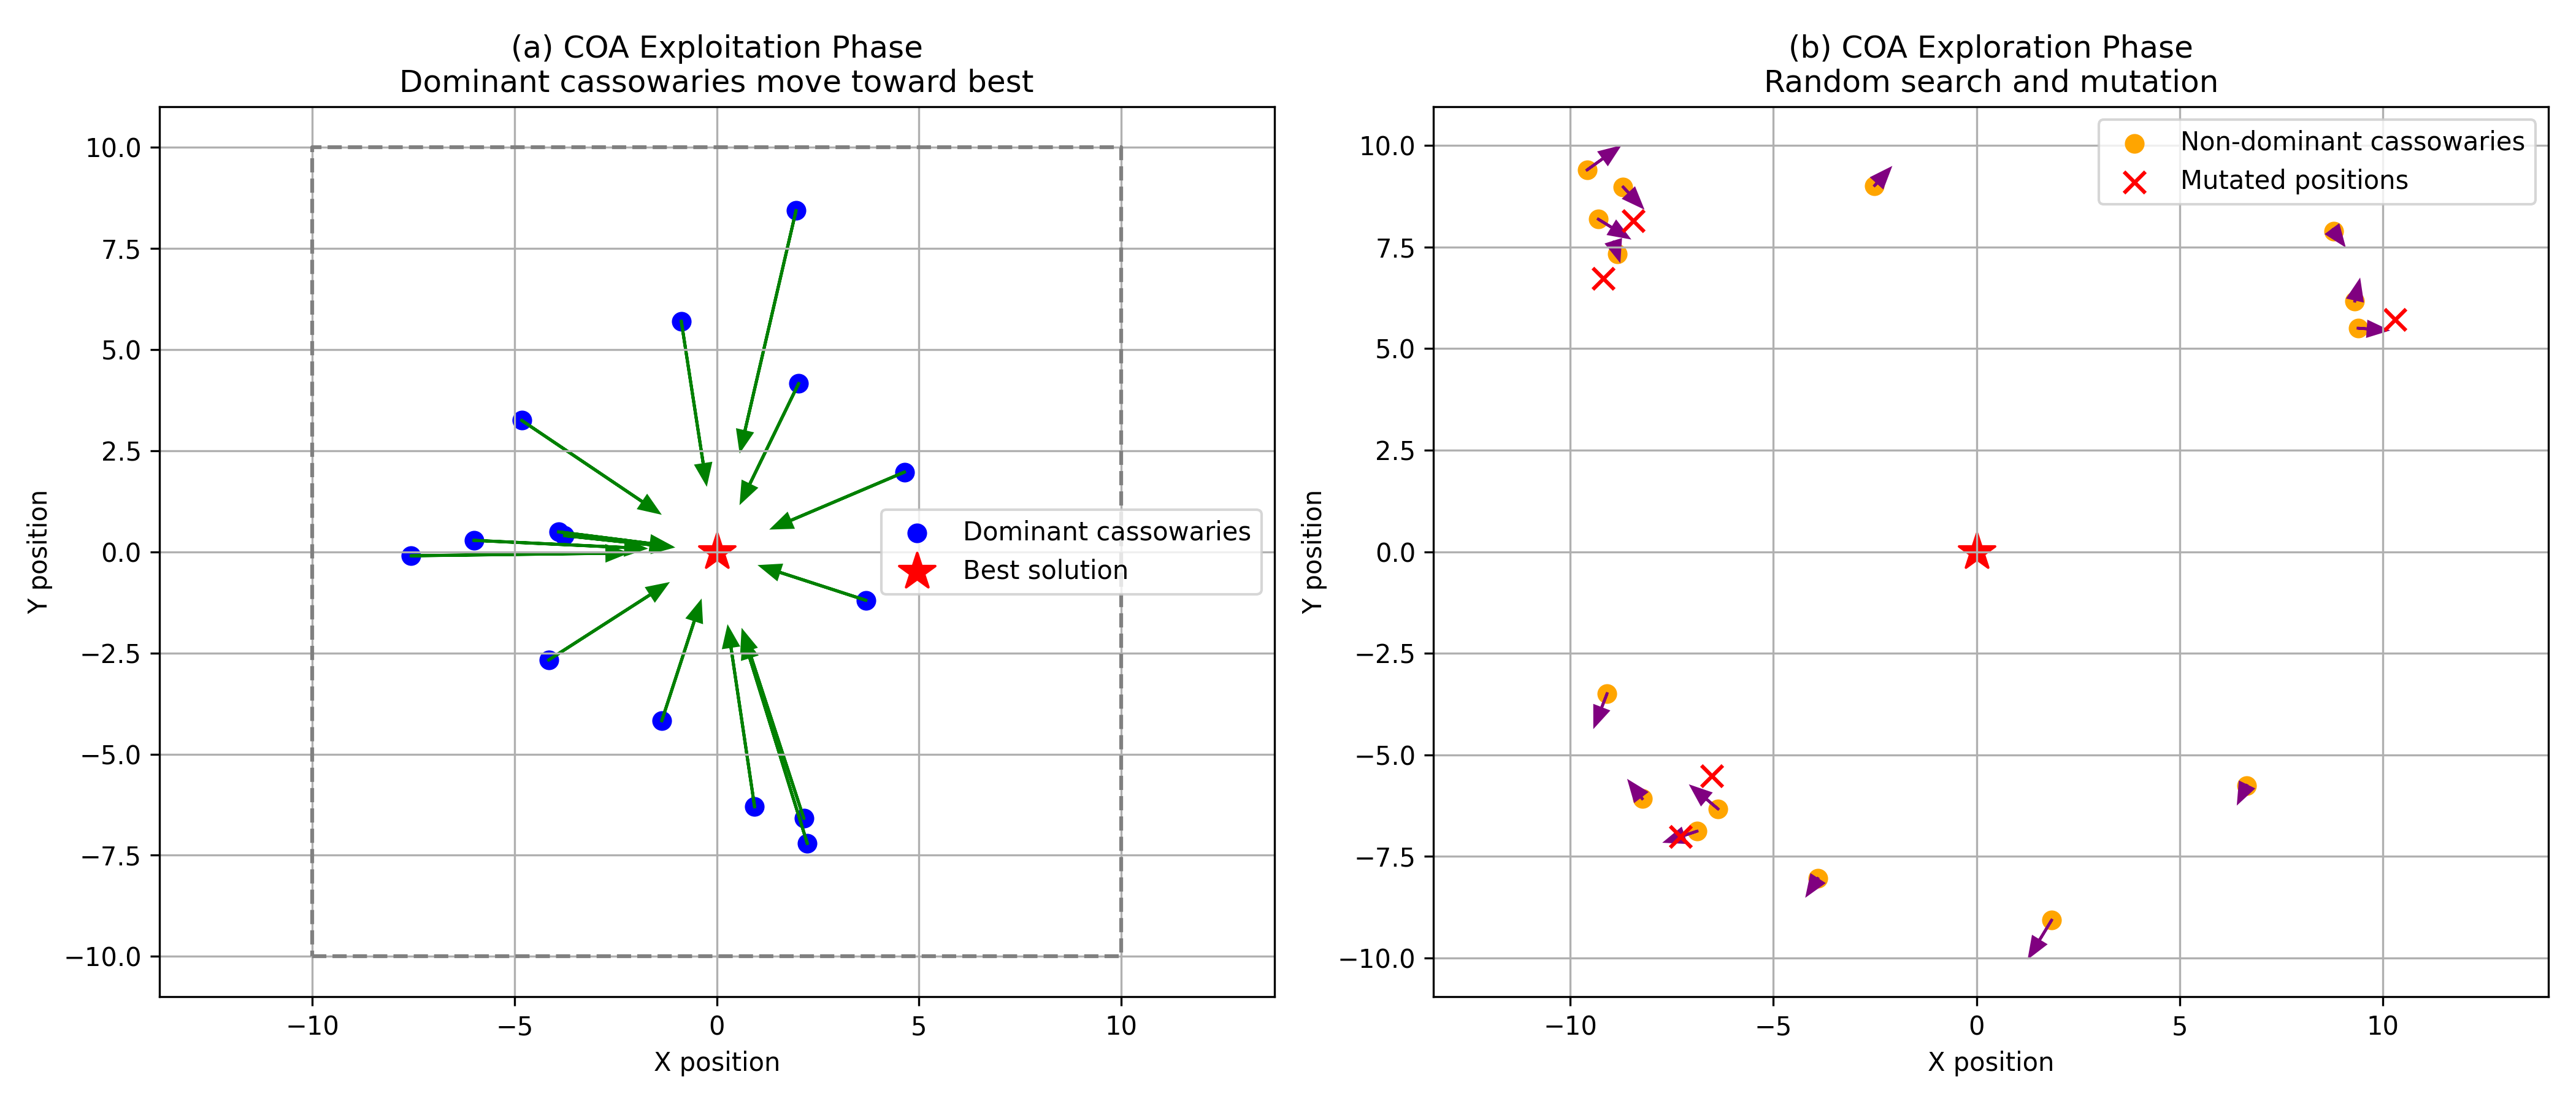

'/content//coa_reproduction_style.png'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CREATE SAVE DIRECTORY
# ============================================================
save_dir = "/content/"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# STEP 1–2: INITIALIZATION
# ============================================================
np.random.seed(42)

N = 30                     # population size
alpha = 0.7                # exploitation step size
beta = 0.9                 # exploration step size
mutation_rate = 0.15

lower_bound, upper_bound = -10, 10

cassowaries = np.random.uniform(
    lower_bound, upper_bound, (N, 2)
)

# Assume global best (for visualization)
X_best = np.array([0.0, 0.0])

# ============================================================
# STEP 6–7: SORT AND SPLIT POPULATION
# ============================================================
fitness = np.linalg.norm(cassowaries - X_best, axis=1)
sorted_idx = np.argsort(fitness)
cassowaries = cassowaries[sorted_idx]

dominant = cassowaries[:N//2]
non_dominant = cassowaries[N//2:]

# ============================================================
# STEP 8–10: DOMINANT CASSOWARY MOVEMENT (EXPLOITATION)
# ============================================================
dominant_moves = []
for x in dominant:
    move = alpha * (X_best - x)
    dominant_moves.append(move)

dominant_moves = np.array(dominant_moves)

# ============================================================
# STEP 11–16: NON-DOMINANT MOVEMENT + MUTATION (EXPLORATION)
# ============================================================
non_dom_moves = []
mutated_points = []

for x in non_dominant:
    move = beta * np.random.uniform(-1, 1, size=2)
    new_x = x + move

    if np.random.rand() < mutation_rate:
        mutation = np.random.uniform(-0.5, 0.5, size=2)
        new_x += mutation
        mutated_points.append(new_x)

    non_dom_moves.append(move)

non_dom_moves = np.array(non_dom_moves)
mutated_points = np.array(mutated_points)

# ============================================================
# PLOT: COA REPRODUCTION-STYLE FIGURE
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------------------------
# (a) Exploitation Phase – Dominant Cassowaries
# ------------------------------------------------------------
ax[0].scatter(dominant[:, 0], dominant[:, 1],
              color="blue", s=45, label="Dominant cassowaries")

ax[0].scatter(X_best[0], X_best[1],
              marker="*", color="red", s=220, label="Best solution")

for i in range(len(dominant)):
    ax[0].arrow(
        dominant[i, 0], dominant[i, 1],
        dominant_moves[i, 0], dominant_moves[i, 1],
        head_width=0.35, head_length=0.45,
        color="green", linewidth=1.2,
        length_includes_head=True
    )

ax[0].plot(
    [lower_bound, upper_bound, upper_bound, lower_bound, lower_bound],
    [lower_bound, lower_bound, upper_bound, upper_bound, lower_bound],
    linestyle="--", color="gray"
)

ax[0].set_title("(a) COA Exploitation Phase\nDominant cassowaries move toward best")
ax[0].set_xlabel("X position")
ax[0].set_ylabel("Y position")
ax[0].grid(True)
ax[0].axis("equal")
ax[0].legend()

# ------------------------------------------------------------
# (b) Exploration + Mutation Phase – Non-dominant Cassowaries
# ------------------------------------------------------------
ax[1].scatter(non_dominant[:, 0], non_dominant[:, 1],
              color="orange", s=45, label="Non-dominant cassowaries")

for i in range(len(non_dominant)):
    ax[1].arrow(
        non_dominant[i, 0], non_dominant[i, 1],
        non_dom_moves[i, 0], non_dom_moves[i, 1],
        head_width=0.35, head_length=0.45,
        color="purple", linewidth=1.1,
        length_includes_head=True
    )

if len(mutated_points) > 0:
    ax[1].scatter(mutated_points[:, 0], mutated_points[:, 1],
                  marker="x", color="red", s=70, label="Mutated positions")

ax[1].scatter(X_best[0], X_best[1],
              marker="*", color="red", s=220)

ax[1].set_title("(b) COA Exploration Phase\nRandom search and mutation")
ax[1].set_xlabel("X position")
ax[1].set_ylabel("Y position")
ax[1].grid(True)
ax[1].axis("equal")
ax[1].legend()

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================
fig_path = f"{save_dir}/coa_reproduction_style.png"
plt.savefig(fig_path, dpi=300)
plt.close()

from IPython.display import display, Image
display(Image(fig_path))

fig_path


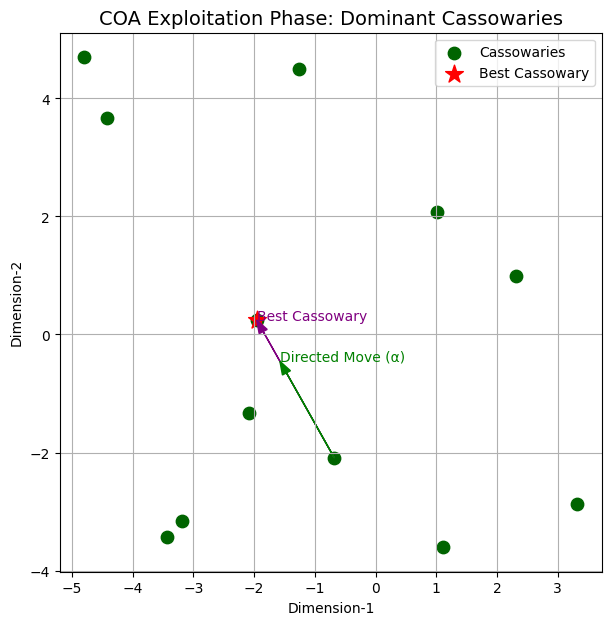

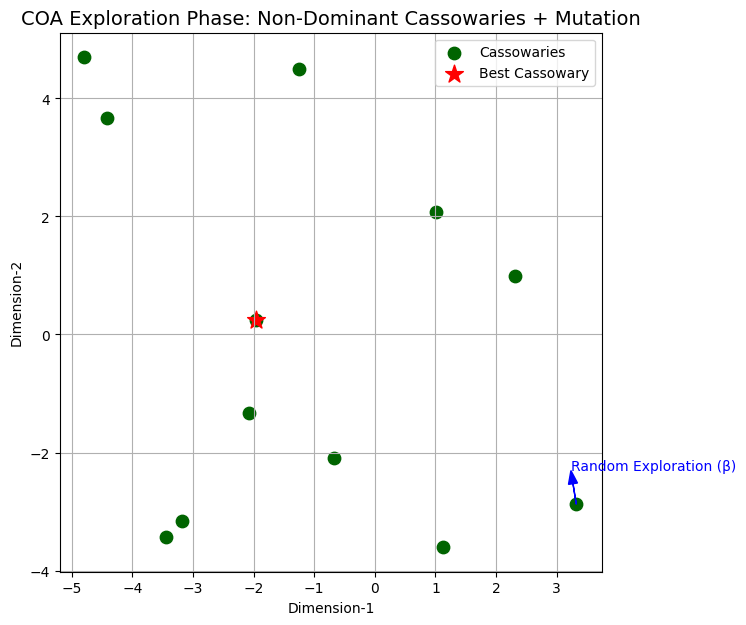

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -------------------------------------------------------------
# Helper: Draw cassowaries and movement vectors
# -------------------------------------------------------------
def plot_cassowaries(positions, best, title, extra_vectors=None):
    plt.figure(figsize=(7,7))
    plt.scatter(positions[:,0], positions[:,1],
                s=80, c='darkgreen', label='Cassowaries')
    plt.scatter(best[0], best[1],
                c='red', s=180, marker='*', label='Best Cassowary')

    if extra_vectors:
        for vec in extra_vectors:
            start, end, color, text = vec
            plt.arrow(start[0], start[1],
                      end[0]-start[0], end[1]-start[1],
                      head_width=0.15, color=color,
                      length_includes_head=True)
            plt.text(end[0], end[1], text,
                     color=color, fontsize=10)

    plt.title(title, fontsize=14)
    plt.xlabel("Dimension-1")
    plt.ylabel("Dimension-2")
    plt.legend()
    plt.grid(True)
    plt.show()


# -------------------------------------------------------------
# STEP 1–2: INITIALIZATION & PARAMETERS
# -------------------------------------------------------------
np.random.seed(42)

N = 12
alpha = 0.7          # exploitation step
beta  = 1.0          # exploration step
mutation_rate = 0.2

lower, upper = -5, 5

cassowaries = np.random.uniform(lower, upper, (N, 2))

# Dummy fitness: distance to origin
fitness = np.linalg.norm(cassowaries, axis=1)

# STEP 5–7: SORT AND SPLIT
sorted_idx = np.argsort(fitness)
cassowaries = cassowaries[sorted_idx]
best = cassowaries[0]

dominant = cassowaries[:N//2]
non_dominant = cassowaries[N//2:]

sample_dom = dominant[1]
sample_non = non_dominant[0]


# -------------------------------------------------------------
# PHASE 1 – DOMINANT CASSOWARIES (EXPLOITATION)
# X_i ← X_i + α (X_best − X_i)
# -------------------------------------------------------------
exploit_step = alpha * (best - sample_dom)
exploit_target = sample_dom + exploit_step

extra_vectors_phase1 = [
    (sample_dom, best, 'purple', 'Best Cassowary'),
    (sample_dom, exploit_target, 'green', 'Directed Move (α)')
]

plot_cassowaries(
    cassowaries,
    best,
    "COA Exploitation Phase: Dominant Cassowaries",
    extra_vectors_phase1
)


# -------------------------------------------------------------
# PHASE 2 – NON-DOMINANT CASSOWARIES (EXPLORATION + MUTATION)
# X_i ← X_i + β·U(−1,1)
# -------------------------------------------------------------
explore_step = beta * np.random.uniform(-1, 1, 2)
explore_target = sample_non + explore_step

extra_vectors_phase2 = [
    (sample_non, explore_target, 'blue', 'Random Exploration (β)')
]

# Mutation
if random.random() < mutation_rate:
    mutation = np.random.uniform(-0.5, 0.5, 2)
    mutated_target = explore_target + mutation
    extra_vectors_phase2.append(
        (explore_target, mutated_target, 'red', 'Mutation')
    )

plot_cassowaries(
    cassowaries,
    best,
    "COA Exploration Phase: Non-Dominant Cassowaries + Mutation",
    extra_vectors_phase2
)


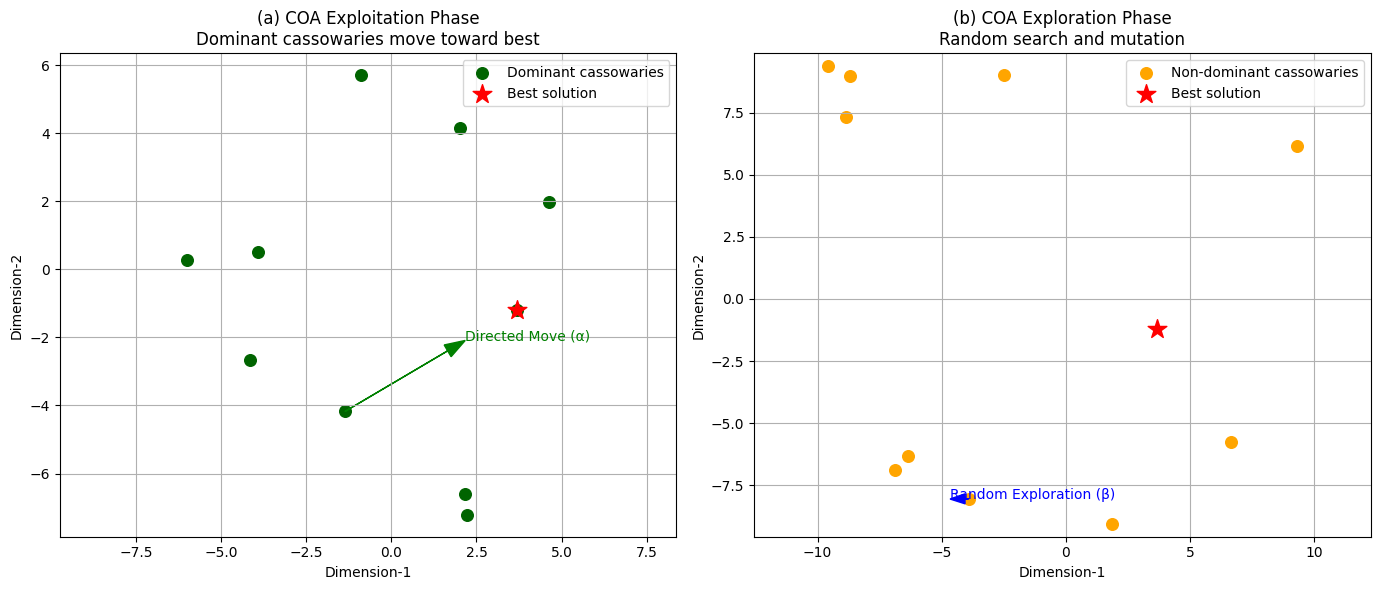

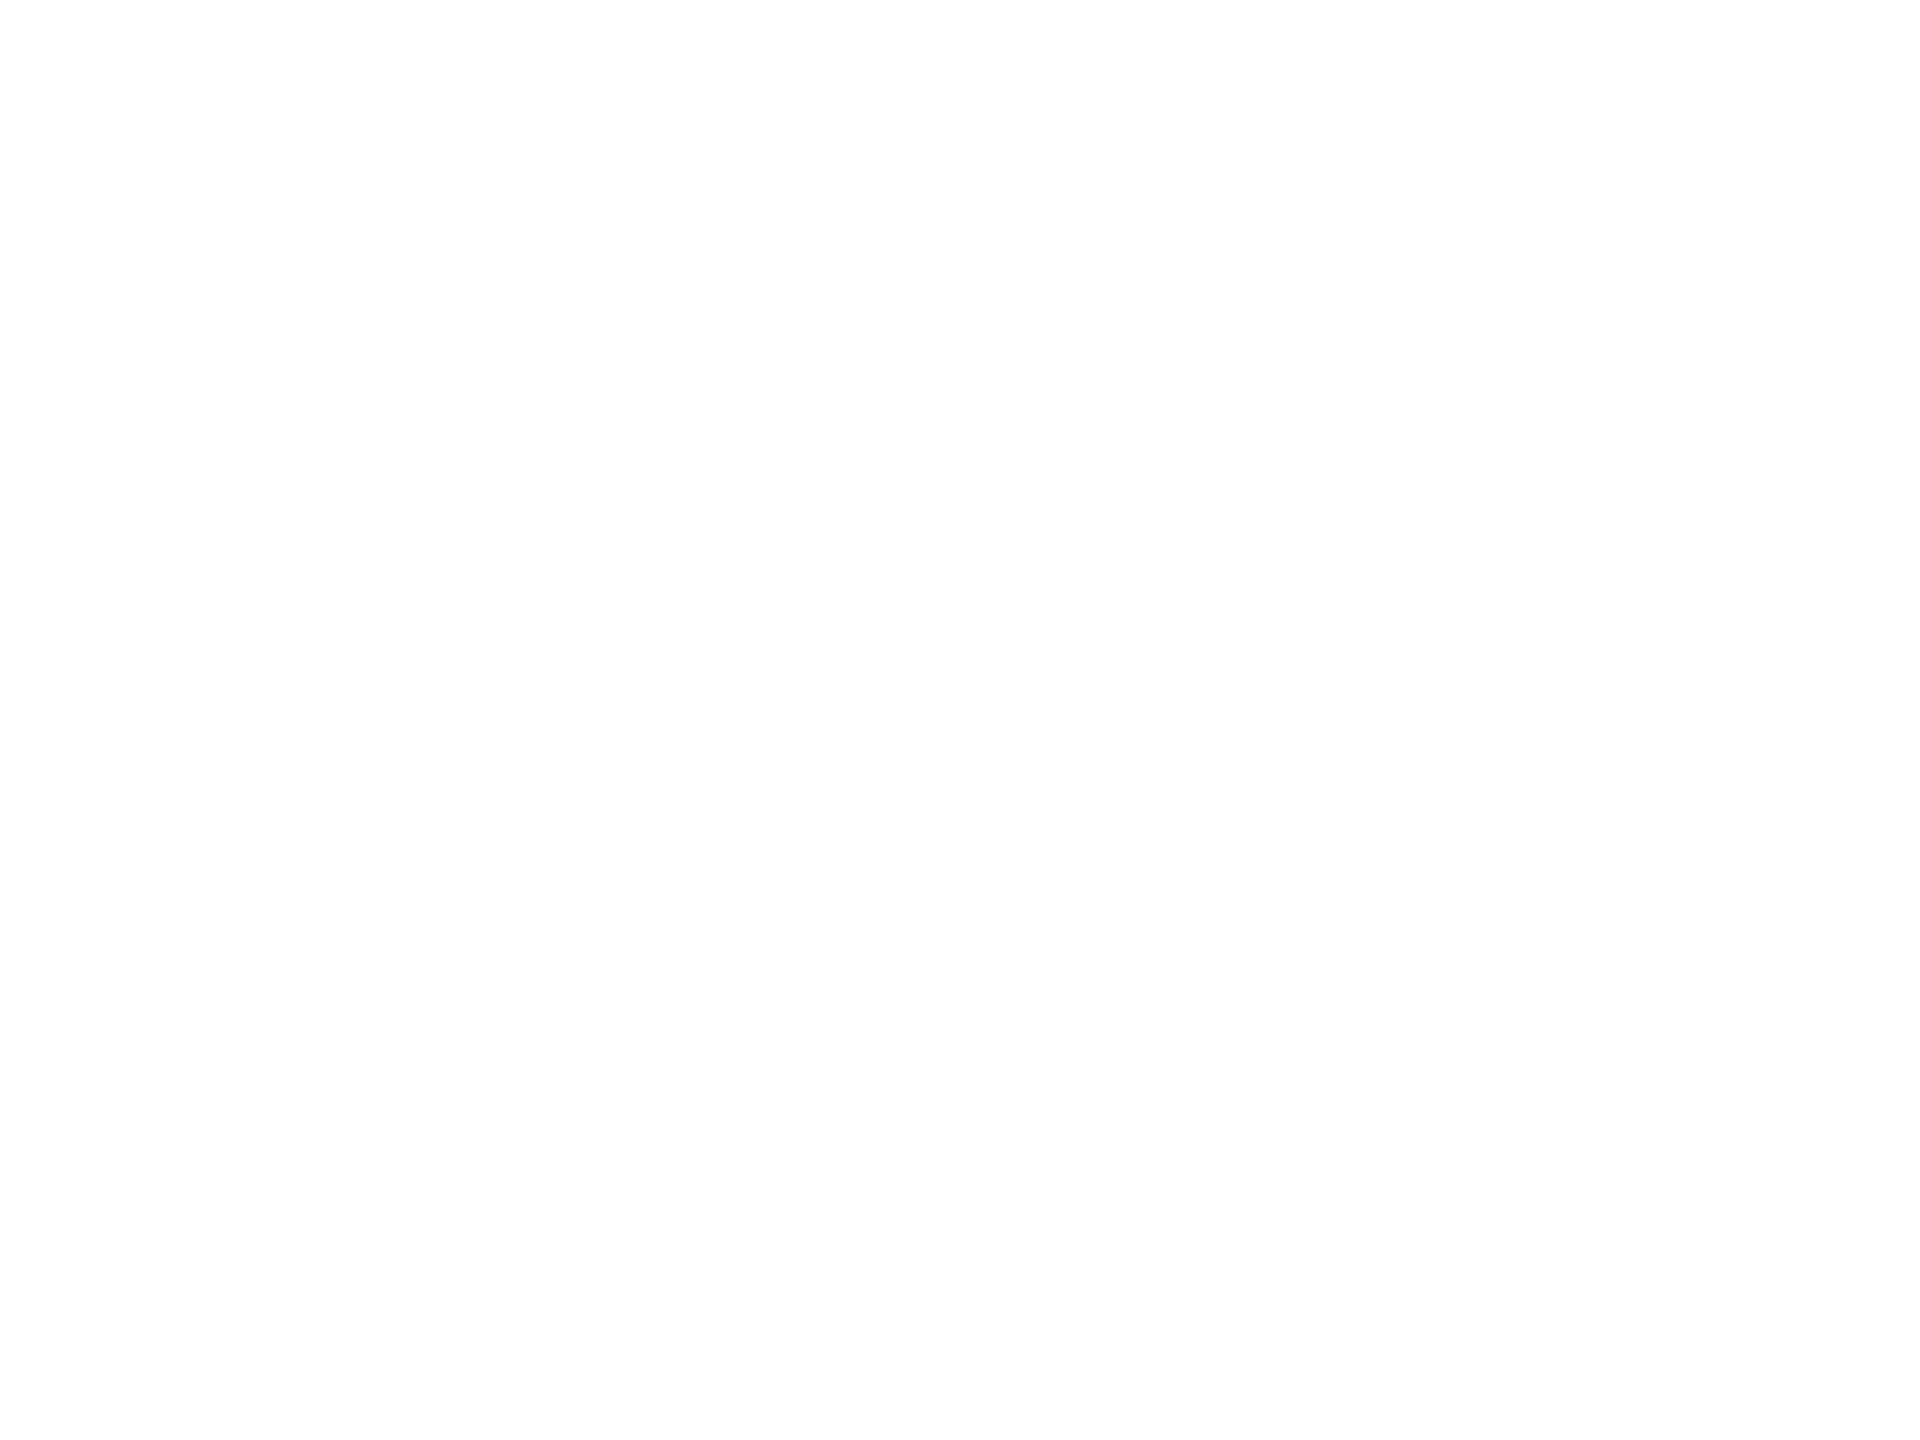

'/content//coa_exploration_style.png'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random



# -------------------------------------------------------------
# INITIALIZATION (Steps 1–2)
# -------------------------------------------------------------
np.random.seed(42)

N = 20
alpha = 0.7
beta = 1.0
mutation_rate = 0.2

lower, upper = -10, 10
cassowaries = np.random.uniform(lower, upper, (N, 2))

# Fitness (distance to origin)
fitness = np.linalg.norm(cassowaries, axis=1)

# -------------------------------------------------------------
# SORT & SPLIT (Steps 5–7)
# -------------------------------------------------------------
idx = np.argsort(fitness)
cassowaries = cassowaries[idx]
best = cassowaries[0]

dominant = cassowaries[:N//2]
non_dominant = cassowaries[N//2:]

# Sample individuals for illustration
dom_sample = dominant[2]
non_sample = non_dominant[1]

# -------------------------------------------------------------
# DOMINANT MOVE (Step 9)
# -------------------------------------------------------------
exploit_target = dom_sample + alpha * (best - dom_sample)

# -------------------------------------------------------------
# NON-DOMINANT MOVE + MUTATION (Steps 12–15)
# -------------------------------------------------------------
explore_target = non_sample + beta * np.random.uniform(-1, 1, 2)

apply_mutation = random.random() < mutation_rate
if apply_mutation:
    mutation_target = explore_target + np.random.uniform(-0.5, 0.5, 2)

# -------------------------------------------------------------
# PLOTTING (Two-Panel Figure)
# -------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# =============================================================
# (a) Exploitation – Dominant Cassowaries
# =============================================================
ax[0].scatter(dominant[:,0], dominant[:,1],
              c='darkgreen', s=70, label="Dominant cassowaries")
ax[0].scatter(best[0], best[1],
              c='red', s=200, marker='*', label="Best solution")

ax[0].arrow(dom_sample[0], dom_sample[1],
            exploit_target[0]-dom_sample[0],
            exploit_target[1]-dom_sample[1],
            head_width=0.4, color='green', length_includes_head=True)

ax[0].text(exploit_target[0], exploit_target[1],
           "Directed Move (α)", color='green')

ax[0].set_title("(a) COA Exploitation Phase\nDominant cassowaries move toward best")
ax[0].set_xlabel("Dimension-1")
ax[0].set_ylabel("Dimension-2")
ax[0].grid(True)
ax[0].axis("equal")
ax[0].legend()

# =============================================================
# (b) Exploration + Mutation – Non-Dominant Cassowaries
# =============================================================
ax[1].scatter(non_dominant[:,0], non_dominant[:,1],
              c='orange', s=70, label="Non-dominant cassowaries")
ax[1].scatter(best[0], best[1],
              c='red', s=200, marker='*', label="Best solution")

ax[1].arrow(non_sample[0], non_sample[1],
            explore_target[0]-non_sample[0],
            explore_target[1]-non_sample[1],
            head_width=0.4, color='blue', length_includes_head=True)

ax[1].text(explore_target[0], explore_target[1],
           "Random Exploration (β)", color='blue')

if apply_mutation:
    ax[1].arrow(explore_target[0], explore_target[1],
                mutation_target[0]-explore_target[0],
                mutation_target[1]-explore_target[1],
                head_width=0.35, color='red', length_includes_head=True)
    ax[1].text(mutation_target[0], mutation_target[1],
               "Mutation", color='red')

ax[1].set_title("(b) COA Exploration Phase\nRandom search and mutation")
ax[1].set_xlabel("Dimension-1")
ax[1].set_ylabel("Dimension-2")
ax[1].grid(True)
ax[1].axis("equal")
ax[1].legend()

plt.tight_layout()
plt.show()



In [ ]:
# ==========================================================
# FULL COA BENCHMARK VISUALIZATION
# 10 Benchmarks × 5 Plots (ONE BIG IMAGE)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------
# Output directory
# ---------------------------
outdir = "/content/"
os.makedirs(outdir, exist_ok=True)

# ---------------------------
# Benchmark functions (2D)
# ---------------------------

def beale(x):
    x1, x2 = x
    return (1.5 - x1 + x1*x2)**2 + (2.25 - x1 + x1*x2**2)**2 + (2.625 - x1 + x1*x2**3)**2

def booth(x):
    x1, x2 = x
    return (x1 + 2*x2 - 7)**2 + (2*x1 + x2 - 5)**2

def bukin6(x):
    x1, x2 = x
    return 100*np.sqrt(abs(x2 - 0.01*x1**2)) + 0.01*abs(x1 + 10)

def three_hump_camel(x):
    x1, x2 = x
    return 2*x1**2 - 1.05*x1**4 + x1**6/6 + x1*x2 + x2**2

def six_hump_camel(x):
    x1, x2 = x
    return ((4 - 2.1*x1**2 + x1**4/3)*x1**2
            + x1*x2 + (-4 + 4*x2**2)*x2**2)

def himmelblau(x):
    x1, x2 = x
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

def matyas(x):
    x1, x2 = x
    return 0.26*(x1**2 + x2**2) - 0.48*x1*x2

def mccormick(x):
    x1, x2 = x
    return np.sin(x1 + x2) + (x1 - x2)**2 - 1.5*x1 + 2.5*x2 + 1

def easom(x):
    x1, x2 = x
    return -np.cos(x1)*np.cos(x2)*np.exp(-((x1-np.pi)**2 + (x2-np.pi)**2))

def levi13(x):
    x1, x2 = x
    return (np.sin(3*np.pi*x1)**2 +
            (x1-1)**2*(1 + np.sin(3*np.pi*x2)**2) +
            (x2-1)**2*(1 + np.sin(2*np.pi*x2)**2))

FUNCTIONS = {
    "Beale": (beale, (-4.5, 4.5)),
    "Booth": (booth, (-10, 10)),
    "Bukin6": (bukin6, (-15, 5)),
    "Three-Hump Camel": (three_hump_camel, (-5, 5)),
    "Six-Hump Camel": (six_hump_camel, (-3, 3)),
    "Himmelblau": (himmelblau, (-5, 5)),
    "Matyas": (matyas, (-10, 10)),
    "McCormick": (mccormick, (-1.5, 4)),
    "Easom": (easom, (-10, 10)),
    "Levi13": (levi13, (-10, 10))
}

# ---------------------------
# Cassowary Optimization Algorithm (COA)
# ---------------------------

def coa_run(func, lb, ub, N=30, max_iter=120, alpha=0.6, beta=1.0, m=0.2, seed=42):
    rng = np.random.RandomState(seed)
    dim = 2

    lb = np.array([lb, lb])
    ub = np.array([ub, ub])

    X = rng.uniform(lb, ub, (N, dim))
    fitness = np.array([func(x) for x in X])

    pos_hist, avg_pos, avg_fit, best_fit = [], [], [], []

    for t in range(max_iter):
        pos_hist.append(X.copy())
        avg_pos.append(np.mean(X, axis=0))
        avg_fit.append(np.mean(fitness))
        best_fit.append(np.min(fitness))

        # Best solution
        best_idx = np.argmin(fitness)
        X_best = X[best_idx]

        # Sort population
        idx = np.argsort(fitness)
        X = X[idx]
        fitness = fitness[idx]

        dominant = X[:N//2]
        non_dominant = X[N//2:]

        # Dominant: exploitation
        for i in range(len(dominant)):
            dominant[i] = dominant[i] + alpha*(X_best - dominant[i])

        # Non-dominant: exploration
        for i in range(len(non_dominant)):
            non_dominant[i] = non_dominant[i] + beta*rng.uniform(-1, 1, dim)

        # Mutation
        if rng.rand() < m:
            j = rng.randint(N)
            X[j] = X[j] + rng.uniform(-0.5, 0.5, dim)

        # Combine & clip
        X = np.vstack((dominant, non_dominant))
        X = np.clip(X, lb, ub)
        fitness = np.array([func(x) for x in X])

    return {
        "positions": np.array(pos_hist),
        "avg_pos": np.array(avg_pos),
        "avg_fit": np.array(avg_fit),
        "best_fit": np.array(best_fit)
    }

# ---------------------------
# BIG COMBINED PLOT (10×5)
# ---------------------------

MAX_ITER = 120
POP_SIZE = 30
SEED = 123

fig, axes = plt.subplots(
    nrows=len(FUNCTIONS),
    ncols=5,
    figsize=(30, 50)
)

for row, (name, (func, bounds)) in enumerate(FUNCTIONS.items()):
    print("Running:", name)

    run = coa_run(func, bounds[0], bounds[1],
                  N=POP_SIZE,
                  max_iter=MAX_ITER,
                  seed=SEED)

    lo, hi = bounds
    X = np.linspace(lo, hi, 250)
    Y = np.linspace(lo, hi, 250)
    xx, yy = np.meshgrid(X, Y)
    zz = np.vectorize(lambda a, b: func([a, b]))(xx, yy)

    final_pos = run["positions"][-1]

    # 1️⃣ Surface
    axes[row,0].contourf(xx, yy, zz, levels=50, cmap='viridis')
    axes[row,0].set_title(f"{name}\nSurface")

    # 2️⃣ Final positions
    axes[row,1].contourf(xx, yy, zz, levels=40, cmap='plasma')
    axes[row,1].scatter(final_pos[:,0], final_pos[:,1], c='red', s=12)
    axes[row,1].set_title("Final positions")

    # 3️⃣ Trajectory
    axes[row,2].contour(xx, yy, zz, levels=30, cmap='gray', linewidths=0.5)
    axes[row,2].plot(run["avg_pos"][:,0], run["avg_pos"][:,1], '-o', markersize=2)
    axes[row,2].set_title("Avg trajectory")

    # 4️⃣ Avg fitness
    axes[row,3].plot(run["avg_fit"])
    axes[row,3].set_yscale('log')
    axes[row,3].set_title("Avg fitness")

    # 5️⃣ Best fitness
    axes[row,4].plot(run["best_fit"])
    axes[row,4].set_yscale('log')
    axes[row,4].set_title("Best convergence")

    for col in range(5):
        axes[row,col].tick_params(labelsize=8)

plt.suptitle(
    "Cassowary Optimization Algorithm (COA) Benchmark Results\n(10 Benchmarks × 5 Metrics)",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

final_img = os.path.join(outdir, "COA_10x5_BIG_RESULTS.png")
plt.savefig(final_img, dpi=300)
plt.show()

print("✅ Final BIG image saved at:", final_img)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==========================================================
# FULL COA BENCHMARK VISUALIZATION
# 7 Benchmarks × 5 Plots (ONE BIG IMAGE)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------
# Output directory
# ---------------------------
outdir = "/content/"
os.makedirs(outdir, exist_ok=True)

# ---------------------------
# Benchmark functions (2D)
# ---------------------------

def ackley(x):
    x = np.asarray(x)
    return (-20*np.exp(-0.2*np.sqrt(0.5*(x[0]**2 + x[1]**2)))
            - np.exp(0.5*(np.cos(2*np.pi*x[0]) + np.cos(2*np.pi*x[1])))
            + np.e + 20)

def rastrigin(x):
    x = np.asarray(x)
    return 20 + (x[0]**2 - 10*np.cos(2*np.pi*x[0])) + (x[1]**2 - 10*np.cos(2*np.pi*x[1]))

def griewank(x):
    x = np.asarray(x)
    return 1 + (x[0]**2 + x[1]**2)/4000 - np.cos(x[0])*np.cos(x[1]/np.sqrt(2))

def levy(x):
    x = np.asarray(x)
    w1 = 1 + (x[0]-1)/4
    w2 = 1 + (x[1]-1)/4
    return (np.sin(np.pi*w1)**2 +
            (w1-1)**2*(1 + 10*np.sin(np.pi*w1+1)**2) +
            (w2-1)**2*(1 + np.sin(2*np.pi*w2)**2))

def bent_cigar(x):
    x = np.asarray(x)
    return x[0]**2 + 1e6 * x[1]**2

def ellipsoid(x):
    x = np.asarray(x)
    return x[0]**2 + 100*x[1]**2

def sphere(x):
    x = np.asarray(x)
    return x[0]**2 + x[1]**2

FUNCTIONS = {
    "Ackley": (ackley, (-5, 5)),
    "Rastrigin": (rastrigin, (-5.12, 5.12)),
    "Griewank": (griewank, (-600, 600)),
    "Levy": (levy, (-10, 10)),
    "BentCigar": (bent_cigar, (-5, 5)),
    "Ellipsoid": (ellipsoid, (-5, 5)),
    "Sphere": (sphere, (-10, 10))
}

# ---------------------------
# Cassowary Optimization Algorithm (COA)
# ---------------------------

def coa_run(func, lb, ub, N=30, max_iter=120,
            alpha=0.6, beta=1.0, m=0.2, seed=42):

    rng = np.random.RandomState(seed)
    dim = 2

    lb = np.array([lb, lb])
    ub = np.array([ub, ub])

    X = rng.uniform(lb, ub, (N, dim))
    fitness = np.array([func(x) for x in X])

    pos_hist, avg_pos, avg_fit, best_fit = [], [], [], []

    for _ in range(max_iter):
        pos_hist.append(X.copy())
        avg_pos.append(np.mean(X, axis=0))
        avg_fit.append(np.mean(fitness))
        best_fit.append(np.min(fitness))

        # Best solution
        best_idx = np.argmin(fitness)
        X_best = X[best_idx]

        # Sort population
        idx = np.argsort(fitness)
        X = X[idx]
        fitness = fitness[idx]

        dominant = X[:N//2]
        non_dominant = X[N//2:]

        # Exploitation
        dominant = dominant + alpha*(X_best - dominant)

        # Exploration
        non_dominant = non_dominant + beta*rng.uniform(-1, 1, size=non_dominant.shape)

        # Combine
        X = np.vstack((dominant, non_dominant))

        # Mutation
        if rng.rand() < m:
            j = rng.randint(N)
            X[j] += rng.uniform(-0.5, 0.5, dim)

        # Clip & evaluate
        X = np.clip(X, lb, ub)
        fitness = np.array([func(x) for x in X])

    return {
        "positions": np.array(pos_hist),
        "avg_pos": np.array(avg_pos),
        "avg_fit": np.array(avg_fit),
        "best_fit": np.array(best_fit)
    }

# ---------------------------
# BIG COMBINED PLOT (7×5)
# ---------------------------

MAX_ITER = 120
POP_SIZE = 30
SEED = 123

fig, axes = plt.subplots(
    nrows=len(FUNCTIONS),
    ncols=5,
    figsize=(30, 38)
)

for row, (name, (func, bounds)) in enumerate(FUNCTIONS.items()):
    print("Running:", name)

    run = coa_run(func, bounds[0], bounds[1],
                  N=POP_SIZE,
                  max_iter=MAX_ITER,
                  seed=SEED)

    lo, hi = bounds
    X = np.linspace(lo, hi, 250)
    Y = np.linspace(lo, hi, 250)
    xx, yy = np.meshgrid(X, Y)
    zz = np.vectorize(lambda a, b: func([a, b]))(xx, yy)

    final_pos = run["positions"][-1]

    # 1️⃣ Surface
    axes[row,0].contourf(xx, yy, zz, levels=50, cmap='viridis')
    axes[row,0].set_title(f"{name}\nSurface")

    # 2️⃣ Final positions
    axes[row,1].contourf(xx, yy, zz, levels=40, cmap='plasma')
    axes[row,1].scatter(final_pos[:,0], final_pos[:,1], c='red', s=12)
    axes[row,1].set_title("Final positions")

    # 3️⃣ Trajectory
    axes[row,2].contour(xx, yy, zz, levels=30, cmap='gray', linewidths=0.5)
    axes[row,2].plot(run["avg_pos"][:,0], run["avg_pos"][:,1], '-o', markersize=2)
    axes[row,2].set_title("Avg trajectory")

    # 4️⃣ Avg fitness
    axes[row,3].plot(run["avg_fit"])
    axes[row,3].set_yscale('log')
    axes[row,3].set_title("Avg fitness")

    # 5️⃣ Best fitness
    axes[row,4].plot(run["best_fit"])
    axes[row,4].set_yscale('log')
    axes[row,4].set_title("Best convergence")

    for col in range(5):
        axes[row,col].tick_params(labelsize=8)

plt.suptitle(
    "Cassowary Optimization Algorithm (COA)\nBenchmark Results (7 Functions × 5 Metrics)",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

final_img = os.path.join(outdir, "COA_7x5_BIG_RESULTS.png")
plt.savefig(final_img, dpi=300)
plt.show()

print("✅ Final BIG image saved at:", final_img)


Output hidden; open in https://colab.research.google.com to view.

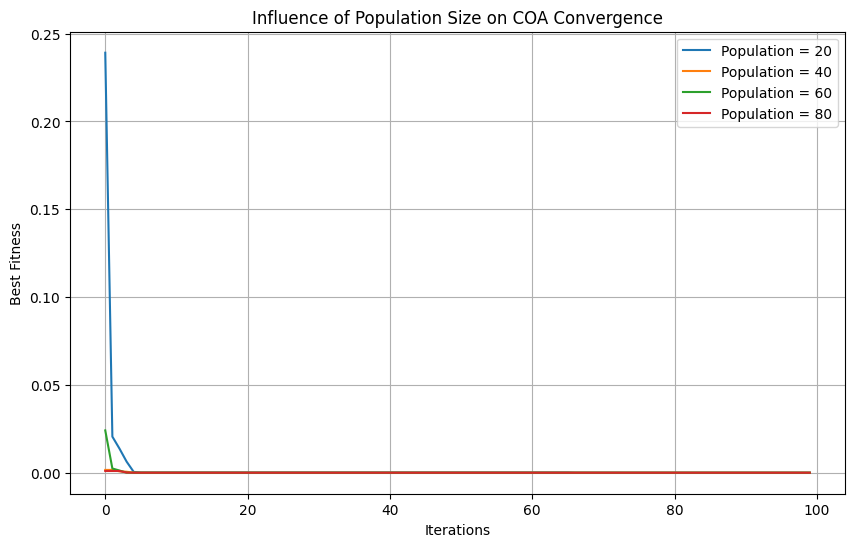

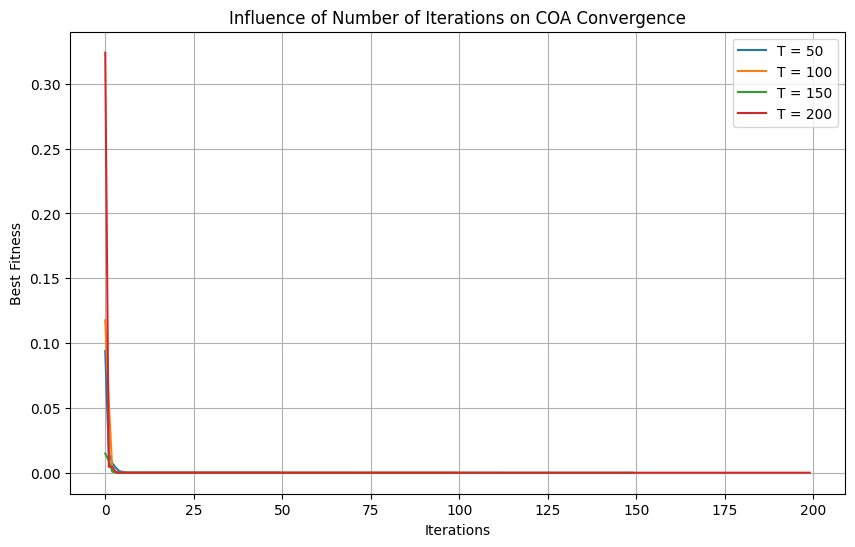

Generated images:
/content/COA_population_influence.png
/content/COA_iteration_influence.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ================================================================
# CASSOWARY OPTIMIZATION ALGORITHM (COA)
# Simplified research plotting version
# ================================================================

def coa_run(f, bounds, N, iterations,
            alpha=0.6, beta=1.0, m=0.2):

    dim = len(bounds)
    lower, upper = np.array(bounds).T

    # Step 1: Initialize population
    X = np.random.uniform(lower, upper, (N, dim))

    # Fitness function
    def fitness(pop):
        return np.array([f(x) for x in pop])

    f_values = fitness(X)
    best_curve = []

    for t in range(iterations):

        # Step 5: Identify best cassowary
        best_idx = np.argmin(f_values)
        X_best = X[best_idx]

        # Step 6: Sort population
        idx = np.argsort(f_values)
        X = X[idx]
        f_values = f_values[idx]

        # Step 7: Split dominant & non-dominant
        dominant = X[:N//2]
        non_dominant = X[N//2:]

        # Step 8–10: Exploitation (dominant)
        for i in range(len(dominant)):
            dominant[i] = dominant[i] + alpha * (X_best - dominant[i])

        # Step 11–13: Exploration (non-dominant)
        for i in range(len(non_dominant)):
            non_dominant[i] = non_dominant[i] + beta * np.random.uniform(-1, 1, dim)

        # Combine population
        X = np.vstack((dominant, non_dominant))

        # Step 14–16: Mutation
        if np.random.rand() < m:
            j = np.random.randint(N)
            X[j] = X[j] + np.random.uniform(-0.5, 0.5, dim)

        # Step 17: Boundary control
        X = np.clip(X, lower, upper)

        # Step 18: Update fitness
        f_values = fitness(X)

        # Store best fitness
        best_curve.append(np.min(f_values))

    # Step 20: Return best curve
    return np.array(best_curve)


# ================================================================
# TEST FUNCTION (Sphere)
# ================================================================

def sphere(x):
    return np.sum(x**2)


# ================================================================
# EXPERIMENT 1: POPULATION SIZE EFFECT
# ================================================================

populations = [20, 40, 60, 80]
iterations = 100
bounds = [(-5, 5), (-5, 5)]

population_results = {}

for pop in populations:
    curve = coa_run(sphere, bounds, pop, iterations)
    population_results[pop] = curve


# ================================================================
# PLOT: Influence of Population Size
# ================================================================

plt.figure(figsize=(10,6))
for pop, curve in population_results.items():
    plt.plot(curve, label=f"Population = {pop}")

plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("Influence of Population Size on COA Convergence")
plt.legend()
plt.grid(True)

plt.savefig("/content/COA_population_influence.png", dpi=300)
plt.show()


# ================================================================
# EXPERIMENT 2: ITERATION COUNT EFFECT
# ================================================================

T_values = [50, 100, 150, 200]
iteration_results = {}

for T in T_values:
    curve = coa_run(sphere, bounds, 40, T)
    iteration_results[T] = curve


# ================================================================
# PLOT: Influence of Number of Iterations
# ================================================================

plt.figure(figsize=(10,6))
for T, curve in iteration_results.items():
    plt.plot(range(len(curve)), curve, label=f"T = {T}")

plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("Influence of Number of Iterations on COA Convergence")
plt.legend()
plt.grid(True)

plt.savefig("/content/COA_iteration_influence.png", dpi=300)
plt.show()


print("Generated images:")
print("/content/COA_population_influence.png")
print("/content/COA_iteration_influence.png")


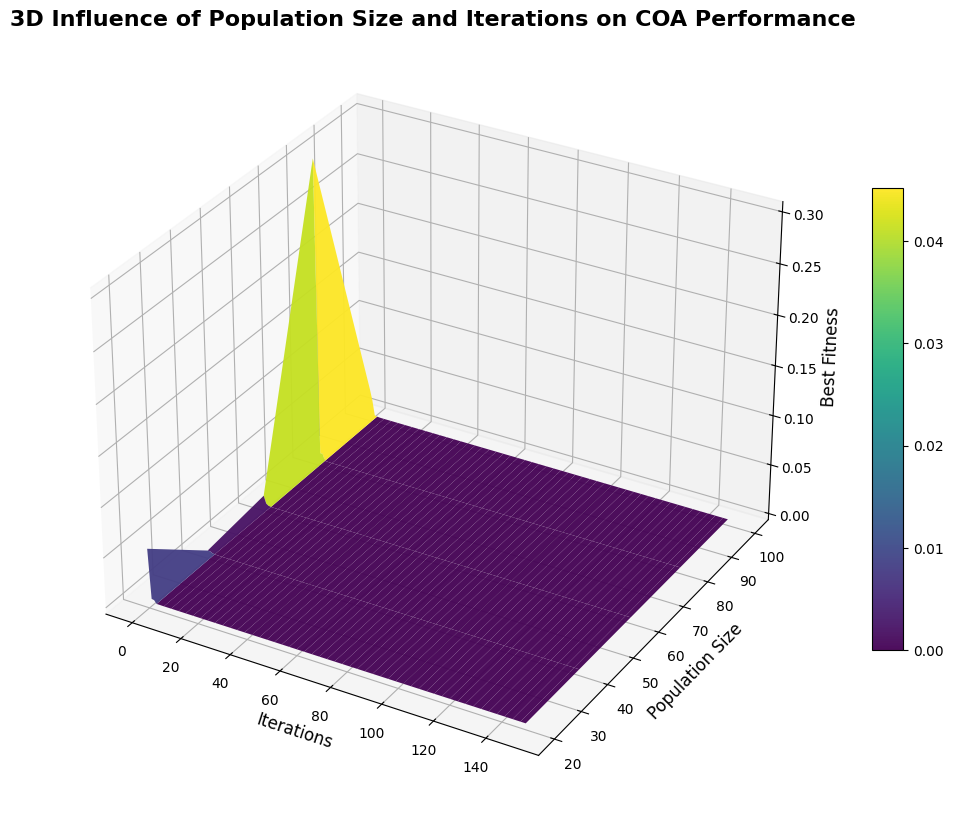

Generated 3D image:
/content/COA_3D_population_iteration_surface.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# ================================================================
# CASSOWARY OPTIMIZATION ALGORITHM (COA)
# Simplified for research visualization
# ================================================================

def coa_run(f, bounds, N, iterations,
            alpha=0.6, beta=1.0, m=0.2):

    dim = len(bounds)
    lower, upper = np.array(bounds).T

    # Step 1: Initialize population
    X = np.random.uniform(lower, upper, (N, dim))

    # Fitness function
    def fitness(pop):
        return np.array([f(x) for x in pop])

    f_values = fitness(X)
    best_curve = []

    for t in range(iterations):

        # Step 5: Identify best cassowary
        best_idx = np.argmin(f_values)
        X_best = X[best_idx]

        # Step 6: Sort population by fitness
        idx = np.argsort(f_values)
        X = X[idx]
        f_values = f_values[idx]

        # Step 7: Split dominant & non-dominant
        dominant = X[:N//2]
        non_dominant = X[N//2:]

        # Step 8–10: Exploitation (dominant cassowaries)
        for i in range(len(dominant)):
            dominant[i] = dominant[i] + alpha * (X_best - dominant[i])

        # Step 11–13: Exploration (non-dominant cassowaries)
        for i in range(len(non_dominant)):
            non_dominant[i] = non_dominant[i] + beta * np.random.uniform(-1, 1, dim)

        # Combine population
        X = np.vstack((dominant, non_dominant))

        # Step 14–16: Mutation
        if np.random.rand() < m:
            j = np.random.randint(N)
            X[j] = X[j] + np.random.uniform(-0.5, 0.5, dim)

        # Step 17: Boundary control
        X = np.clip(X, lower, upper)

        # Step 18: Update fitness
        f_values = fitness(X)

        # Record best fitness
        best_curve.append(np.min(f_values))

    # Step 20: Return best convergence curve
    return np.array(best_curve)


# ================================================================
# TEST FUNCTION (Sphere)
# ================================================================

def sphere(x):
    return np.sum(x**2)


# ================================================================
# EXPERIMENT GRID: POPULATIONS × ITERATIONS
# ================================================================

populations = [20, 40, 60, 80, 100]
iterations = 150
bounds = [(-5, 5), (-5, 5)]

Z = []

for pop in populations:
    curve = coa_run(sphere, bounds, pop, iterations)
    Z.append(curve)

Z = np.array(Z)

# Meshgrid
X_iter = np.arange(iterations)
Y_pop = np.array(populations)
X, Y = np.meshgrid(X_iter, Y_pop)

# ================================================================
# 3D SURFACE PLOT
# ================================================================

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.95
)

ax.set_title(
    "3D Influence of Population Size and Iterations on COA Performance",
    fontsize=16, fontweight='bold'
)
ax.set_xlabel("Iterations", fontsize=12)
ax.set_ylabel("Population Size", fontsize=12)
ax.set_zlabel("Best Fitness", fontsize=12)

fig.colorbar(surf, shrink=0.6, aspect=15)

plt.savefig("/content/COA_3D_population_iteration_surface.png", dpi=300)
plt.show()

print("Generated 3D image:")
print("/content/COA_3D_population_iteration_surface.png")


In [ ]:
# COA_benchmarks_all5.py
# Paste into Google Colab and run. Outputs saved to /content/

import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# ---------- output dir ----------
outdir = "/content/coa_benchmarks/"
os.makedirs(outdir, exist_ok=True)



# 1) Cantilever beam
def cantilever_obj(x):
    return 0.06224 * np.sum(x)

def cantilever_constraints(x):
    g = (61.0 / x[0]**3 +
         37.0 / x[1]**3 +
         19.0 / x[2]**3 +
         7.0  / x[3]**3 +
         1.0  / x[4]**3 - 1.0)
    return [g]

cantilever_bounds = [(0.01, 100)] * 5


# 2) Welded beam (simplified)
def welded_obj(x):
    h, l, t, b = x
    return 1.10471*h*h*l + 0.04811*t*b*(14.0 + l)

def welded_constraints(x):
    return [0.0, 0.0]

welded_bounds = [(0.1, 10)] * 4


# 3) Pressure vessel
def pressure_obj(x):
    Ts, Th, R, L = x
    return (0.6224*Ts*R*L +
            1.7781*Th*R**2 +
            3.1661*Ts**2*L +
            19.84*Ts**2*R)

def pressure_constraints(x):
    Ts, Th, R, L = x
    Vmin = 1296000.0
    vol = np.pi * R**2 * L + 4/3*np.pi*R**3
    return [max(0.0, Vmin - vol)]

pressure_bounds = [(0.0625, 10.0),
                   (0.0625, 10.0),
                   (10.0, 200.0),
                   (10.0, 200.0)]


# 4) Speed reducer
def speed_reducer_obj(x):
    x1,x2,x3,x4,x5,x6,x7 = x
    return (0.7854*x1*x2**2*(3.3333*x3**2 + 14.9334*x3 - 43.0934)
            - 1.508*x1*(x6**2 + x7**2)
            + 7.477*(x6**3 + x7**3))

def speed_reducer_constraints(x):
    return [0.0]

speed_reducer_bounds = [(2.6,3.6),(0.7,0.8),(17,28),
                        (7.3,8.3),(7.3,8.3),(2.9,3.9),(5.0,5.5)]


# 5) Compression spring
def spring_obj(x):
    d, D, N = x
    return (N + 2.0) * D * d**2

def spring_constraints(x):
    return [0.0]

spring_bounds = [(0.05,2.0),(0.25,1.3),(2,15)]


PROBLEMS = [
    ("Cantilever", cantilever_obj, cantilever_constraints, cantilever_bounds),
    ("WeldedBeam", welded_obj, welded_constraints, welded_bounds),
    ("PressureVessel", pressure_obj, pressure_constraints, pressure_bounds),
    ("SpeedReducer", speed_reducer_obj, speed_reducer_constraints, speed_reducer_bounds),
    ("CompressionSpring", spring_obj, spring_constraints, spring_bounds),
]

# ================================================================
# Cassowary Optimization Algorithm (COA)
# As per your 20-step procedure
# ================================================================

def coa_optimize(obj_func, cons_func, bounds,
                 N=60, iterations=220,
                 alpha=0.6, beta=1.0, m=0.2, seed=None):

    rng = np.random.RandomState(seed)
    dim = len(bounds)
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])

    # Step 1: Initialize population
    X = rng.uniform(lb, ub, (N, dim))

    def fitness(x):
        pen = 0.0
        for g in cons_func(x):
            if g > 0:
                pen += 1e9 * g**2
        return obj_func(x) + pen

    fvals = np.array([fitness(x) for x in X])

    history = {"positions": [], "avg_pos": [], "avg_fit": [], "best_fit": []}

    for t in range(iterations):

        # Logging
        history["positions"].append(X.copy())
        history["avg_pos"].append(X.mean(axis=0))
        history["avg_fit"].append(fvals.mean())
        history["best_fit"].append(fvals.min())

        # Step 5–6: Best & sort
        idx = np.argsort(fvals)
        X = X[idx]
        fvals = fvals[idx]
        X_best = X[0]

        # Step 7: Dominant & non-dominant
        dominant = X[:N//2]
        non_dominant = X[N//2:]

        # Step 8–10: Exploitation
        for i in range(len(dominant)):
            dominant[i] = dominant[i] + alpha * (X_best - dominant[i])

        # Step 11–13: Exploration
        for i in range(len(non_dominant)):
            non_dominant[i] = non_dominant[i] + beta * rng.uniform(-1, 1, dim)

        # Combine
        X = np.vstack((dominant, non_dominant))

        # Step 14–16: Mutation
        if rng.rand() < m:
            j = rng.randint(N)
            X[j] = X[j] + rng.uniform(-0.5, 0.5, dim)

        # Step 17: Boundary control
        X = np.clip(X, lb, ub)

        # Step 18: Fitness update
        fvals = np.array([fitness(x) for x in X])

    return {
        "gbest": X[np.argmin(fvals)],
        "gbest_f": fvals.min(),
        "history": history
    }

# ================================================================
# Composite Plot (unchanged, reused)
# ================================================================

def make_composite_plot(name, obj_func, runhist, bounds, outpath):

    dim = len(bounds)
    fig = plt.figure(figsize=(15,10))
    gs = fig.add_gridspec(2,3, hspace=0.35, wspace=0.35)

    ax1 = fig.add_subplot(gs[0,0])
    vals = np.array(runhist["best_fit"])
    ax1.plot(vals, '-o', markersize=3)
    ax1.set_title("Best fitness over iterations")

    ax2 = fig.add_subplot(gs[0,1])
    pop = runhist["positions"][-1]
    ax2.scatter(pop[:,0], pop[:,1] if dim > 1 else np.zeros(len(pop)), s=20)
    ax2.set_title("Final population (projection)")

    ax3 = fig.add_subplot(gs[0,2])
    avg = np.array(runhist["avg_pos"])
    ax3.plot(avg[:,0], avg[:,1] if dim > 1 else np.zeros(len(avg)))
    ax3.set_title("Average trajectory")

    ax4 = fig.add_subplot(gs[1,0])
    ax4.plot(runhist["avg_fit"])
    ax4.set_yscale("log")
    ax4.set_title("Average fitness (log)")

    ax5 = fig.add_subplot(gs[1,1])
    ax5.plot(runhist["best_fit"], color="orange")
    ax5.set_yscale("log")
    ax5.set_title("Best convergence")

    ax6 = fig.add_subplot(gs[1,2])
    ax6.axis("off")

    plt.suptitle(f"COA Benchmark Visualization — {name}")
    plt.savefig(outpath, dpi=200)
    plt.close()

# ================================================================
# Run COA on all benchmarks
# ================================================================

rows = []

for name, obj, cons, bounds in PROBLEMS:
    print("Running COA:", name)
    res = coa_optimize(obj, cons, bounds, seed=1234)
    make_composite_plot(
        name, obj, res["history"], bounds,
        os.path.join(outdir, f"{name}_COA_composite.png")
    )
    rows.append([name] + list(res["gbest"]) + [res["gbest_f"]])

cols = ["Problem"] + [f"x{i+1}" for i in range(max(len(b) for _,_,_,b in PROBLEMS))] + ["best_f"]
df = pd.DataFrame(rows, columns=cols)
df.to_csv(os.path.join(outdir, "COA_results_summary.csv"), index=False)

print("All COA benchmarks completed.")


Running COA: Cantilever
Running COA: WeldedBeam
Running COA: PressureVessel
Running COA: SpeedReducer
Running COA: CompressionSpring
All COA benchmarks completed.
